# Example #1: Governing Law clause analysis

_This notebook builds on the quickstart guide. If you're new to Python/Jupyter and haven't read the quickstart yet, we recommend starting there._

**What is this?**
- This notebook features a basic analysis of Governing Law clauses (standard ID `5e59453aaa9255c4`) and Forum Selection clauses (standard ID `f758e6a8d32690bd`)
  
**Prerequisites**
- Run `pip install requests pandas seaborn matplotlib numpy textstat`
  - This will install `requests`, `pandas`, `seaborn`, `matplotlib`, `numpy`, and `textstat` (if not already installed)
- Obtain an API key from [pandects.org](https://pandects.org) and export it as `PANDECTS_API_KEY`

## Imports and setup

In [1]:
import os
import re
import time
from collections import Counter
import xml.dom.minidom
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import textstat

pd.set_option('display.max_rows', None)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
# Configuration
API_BASE_URL = "https://api.pandects.org"
API_KEY = os.getenv("PANDECTS_API_KEY")

if not API_KEY:
    raise RuntimeError(
        "Missing PANDECTS_API_KEY. Export your key (starts with pdcts_) and re-run this cell."
    )

session = requests.Session()
session.headers.update({"Accept": "application/json", "X-API-Key": API_KEY})


## Shared utils

In [3]:
DEAL_TYPE_MAP = {
    "merger": "Merger",
    "stock_acquisition": "Stock acquisition",
    "asset_acquisition": "Asset acquisition",
    "membership_interest_purchase": "Membership interest",
    "tender_offer": "Tender offer",
}

US_STATES = [
    "Alabama",
    "Alaska",
    "Arizona",
    "Arkansas",
    "California",
    "Colorado",
    "Connecticut",
    "Delaware",
    "Florida",
    "Georgia",
    "Hawaii",
    "Idaho",
    "Illinois",
    "Indiana",
    "Iowa",
    "Kansas",
    "Kentucky",
    "Louisiana",
    "Maine",
    "Maryland",
    "Massachusetts",
    "Michigan",
    "Minnesota",
    "Mississippi",
    "Missouri",
    "Montana",
    "Nebraska",
    "Nevada",
    "New Hampshire",
    "New Jersey",
    "New Mexico",
    "New York",
    "North Carolina",
    "North Dakota",
    "Ohio",
    "Oklahoma",
    "Oregon",
    "Pennsylvania",
    "Rhode Island",
    "South Carolina",
    "South Dakota",
    "Tennessee",
    "Texas",
    "Utah",
    "Vermont",
    "Virginia",
    "Washington",
    "West Virginia",
    "Wisconsin",
    "Wyoming",
]

FOREIGN_JURISDICTIONS = [
    "Australia", "Australian",
    "Austria", "Austrian",
    "Belgium", "Belgian",
    "Canada", "Canadian",
    "Chile", "Chilean",
    "Croatia", "Croatian",
    "Cyprus", "Cypriot",
    "Czechia", "Czech",
    "Denmark", "Danish",
    "Estonia", "Estonian",
    "Finland", "Finnish",
    "France", "French",
    "Germany", "German",
    "Greece", "Greek",
    "Hong Kong", "Hong Kong",
    "Hungary", "Hungarian",
    "Iceland", "Icelandic",
    "Ireland", "Irish",
    "Israel", "Israeli",
    "Italy", "Italian",
    "Japan", "Japanese",
    "Latvia", "Latvian",
    "Liechtenstein", "Liechtenstein",
    "Lithuania", "Lithuanian",
    "Luxembourg", "Luxembourgish",
    "Malta", "Maltese",
    "Netherlands", "Dutch",
    "New Zealand", "New Zealand",
    "Norway", "Norwegian",
    "Poland", "Polish",
    "Portugal", "Portuguese",
    "Romania", "Romanian",
    "Singapore", "Singaporean",
    "Slovakia", "Slovak",
    "Slovenia", "Slovenian",
    "South Korea", "South Korean",
    "Spain", "Spanish",
    "Sweden", "Swedish",
    "Switzerland", "Swiss",
    "Taiwan", "Taiwanese",
    "United Arab Emirates", "Emirati",
    "United Kingdom", "British",
    "Andorra", "Andorran",
    "Monaco", "Monegasque",
    "San Marino", "Sammarinese",
    "Qatar", "Qatari",
    "Saudi Arabia", "Saudi",
    "Kuwait", "Kuwaiti",
    "Bahrain", "Bahraini",
]

JURISDICTIONS = US_STATES + FOREIGN_JURISDICTIONS

_state_re = re.compile(
    r"\b(?:"
    + "|".join(re.escape(s) for s in sorted(JURISDICTIONS, key=len, reverse=True))
    + r")\b",
    flags=re.IGNORECASE,
)
_state_canon = {s.lower(): s for s in JURISDICTIONS}


def canon_unique(matches):
    if not matches:
        return ["N/A"]

    seen = set()
    out = []
    for match in matches:
        key = match.lower()
        if key not in seen:
            seen.add(key)
            out.append(_state_canon[key])
    return sorted(out)


def download_sections_for_standard_id(
    session,
    api_base_url,
    clause_type_id,
    *,
    page_size=100,
    metadata=None,
    progress_every=10,
    pause_s=1.0,
):
    metadata = metadata or []
    page = 1
    sections = []

    start_time = time.time()
    while True:
        response = session.get(
            f"{api_base_url}/v1/sections",
            params={
                "standard_id": clause_type_id,
                "page": page,
                "page_size": page_size,
                "metadata": metadata,
            },
            timeout=30,
        )
        response.raise_for_status()
        payload = response.json()

        batch = payload["results"]
        sections.extend(batch)

        current_page = payload["page"]
        total_pages = payload["total_pages"]
        if current_page % progress_every == 0 or not payload.get("has_next"):
            elapsed = time.time() - start_time
            print(
                f"Progress: page {current_page}/{total_pages} | sections={len(sections)} | elapsed={elapsed:.1f}s"
            )

        if not payload.get("has_next"):
            break

        page = payload["next_num"]
        time.sleep(pause_s)

    elapsed_total = time.time() - start_time
    print(f"Returned sections: {len(sections)}")
    print(f"Access tier: {payload.get('access', {}).get('tier')}")
    print(f"Total download time: {elapsed_total:.1f}s")

    if not sections:
        raise RuntimeError(f"No sections found for standard_id={clause_type_id}")

    return sections


def prepare_clause_df(sections, deal_type_map=DEAL_TYPE_MAP):
    df = pd.DataFrame(sections)
    if df.empty:
        raise RuntimeError("No sections were returned.")

    metadata_df = pd.json_normalize(df["metadata"]).reindex(df.index)
    df = df.join(metadata_df)
    df["deal_type"] = df["deal_type"].map(deal_type_map)
    return df.drop_duplicates(subset="agreement_uuid", keep=False).copy()


def add_state_columns(df):
    df = df.copy()
    hits = df["xml"].fillna("").str.findall(_state_re)
    df["states"] = hits.map(canon_unique)
    df["mentions_delaware"] = df["states"].apply(lambda xs: "Delaware" in xs)
    df["mentions_new_york"] = df["states"].apply(lambda xs: "New York" in xs)
    df["only_delaware"] = df["states"].apply(lambda xs: xs == ["Delaware"])
    df["only_new_york"] = df["states"].apply(lambda xs: xs == ["New York"])
    return df


def build_taxonomy_lookup(taxonomy):
    id_to_full_path = {}
    id_to_leaf = {}

    l1_items = taxonomy.items() if isinstance(taxonomy, dict) else taxonomy
    for l1_title, l1_node in l1_items:
        id_to_full_path[l1_node["id"]] = l1_title
        id_to_leaf[l1_node["id"]] = l1_title

        for l2_title, l2_node in (l1_node.get("children") or {}).items():
            full_l2 = f"{l1_title} > {l2_title}"
            id_to_full_path[l2_node["id"]] = full_l2
            id_to_leaf[l2_node["id"]] = l2_title

            for l3_title, l3_node in (l2_node.get("children") or {}).items():
                full_l3 = f"{l1_title} > {l2_title} > {l3_title}"
                id_to_full_path[l3_node["id"]] = full_l3
                id_to_leaf[l3_node["id"]] = l3_title

    return {"leaf": id_to_leaf, "full_path": id_to_full_path}


def fetch_taxonomy_lookup(session, api_base_url):
    response = session.get(f"{api_base_url}/v1/taxonomy", timeout=30)
    response.raise_for_status()
    return build_taxonomy_lookup(response.json())


def _standard_id_list(value):
    if value is None:
        return []
    if isinstance(value, list):
        return value
    return [value]


def add_taxonomy_text_columns(df, taxonomy_lookup):
    df = df.copy()
    id_to_leaf = taxonomy_lookup["leaf"]
    id_to_full_path = taxonomy_lookup["full_path"]

    df["standard_id_text"] = df["standard_id"].apply(
        lambda value: None
        if value is None
        else " | ".join(id_to_leaf.get(item, str(item)) for item in _standard_id_list(value))
    )
    df["standard_id_full_text"] = df["standard_id"].apply(
        lambda value: None
        if value is None
        else " | ".join(id_to_full_path.get(item, str(item)) for item in _standard_id_list(value))
    )
    return df


def is_clause_family_only(standard_ids, clause_type_id):
    return _standard_id_list(standard_ids) == [clause_type_id]


def is_clause_family_eligible(standard_ids, states, clause_type_id):
    standard_id_list = _standard_id_list(standard_ids)
    return standard_id_list == [clause_type_id] or (
        clause_type_id in standard_id_list and len(states) == 1
    )


def xml_to_text(xml_series):
    return (
        xml_series.fillna("")
        .str.replace(r"<[^>]+>", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def wilson_ci(k, n, z=1.96):
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n)) / denom
    lo = np.clip(center - half, 0, 1)
    hi = np.clip(center + half, 0, 1)
    return lo, hi


def phi_coefficient(x, y):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    if x.nunique(dropna=True) < 2 or y.nunique(dropna=True) < 2:
        return np.nan
    return x.corr(y)


## Governing Law analysis

### Download
Paginate through all matching sections for clause type `5e59453aaa9255c4`, which is the taxonomy ID for Governing Law clauses.

In [4]:
GOV_LAW_CLAUSE_TYPE_ID = "5e59453aaa9255c4"

sections_gov = download_sections_for_standard_id(
    session,
    API_BASE_URL,
    GOV_LAW_CLAUSE_TYPE_ID,
    metadata=["deal_type", "acquirer_type", "target_type", "transaction_consideration", "transaction_price_cash"],
)


Progress: page 10/11 | sections=1000 | elapsed=69.8s
Progress: page 20/21 | sections=2000 | elapsed=139.2s
Progress: page 30/31 | sections=3000 | elapsed=194.9s
Progress: page 40/41 | sections=4000 | elapsed=244.1s
Progress: page 50/51 | sections=5000 | elapsed=297.7s
Progress: page 60/61 | sections=6000 | elapsed=363.7s
Progress: page 70/71 | sections=7000 | elapsed=416.0s
Progress: page 80/81 | sections=8000 | elapsed=455.0s
Progress: page 87/87 | sections=8651 | elapsed=479.8s
Returned sections: 8651
Access tier: api_key
Total download time: 479.8s


In [5]:
df_gov = prepare_clause_df(sections_gov)
df_gov.head(1)


,acquirer,agreement_uuid,article_title,id,metadata,section_title,section_uuid,standard_id,target,verified,xml,year,acquirer_type,deal_type,target_type,transaction_consideration,transaction_price_cash
0,CINTAS CORPORATION,8f3084d0-f42d-5bb7-9f6a-a4a51e55a1b4,Article VIII General Provisions,c79ddd26-7629-5ee1-844b-05553214bd18,"{'acquirer_type': 'public', 'deal_type': 'merg...",Section 8.9 Governing Law.,c79ddd26-7629-5ee1-844b-05553214bd18,[5e59453aaa9255c4],UNIFIRST CORPORATION,False,\n <text>This Agreement and all Proceed...,2026,public,Merger,public,mixed,2.802353e+09


In [6]:
print(df_gov.shape)


(8601, 17)


In [7]:
df_gov["deal_type"].value_counts(dropna=False)


deal_type
Merger                 6082
Stock acquisition      1113
Membership interest     685
Asset acquisition       595
Tender offer            113
NaN                      13
Name: count, dtype: int64

In [8]:
df_gov.shape


(8601, 17)

In [9]:
df_gov.head()


,acquirer,agreement_uuid,article_title,id,metadata,section_title,section_uuid,standard_id,target,verified,xml,year,acquirer_type,deal_type,target_type,transaction_consideration,transaction_price_cash
0,CINTAS CORPORATION,8f3084d0-f42d-5bb7-9f6a-a4a51e55a1b4,Article VIII General Provisions,c79ddd26-7629-5ee1-844b-05553214bd18,"{'acquirer_type': 'public', 'deal_type': 'merg...",Section 8.9 Governing Law.,c79ddd26-7629-5ee1-844b-05553214bd18,[5e59453aaa9255c4],UNIFIRST CORPORATION,False,\n <text>This Agreement and all Proceed...,2026,public,Merger,public,mixed,2.802353e+09
1,"Universal Health Services, Inc.",7633544b-9b1b-56f8-a0bd-7dea012fb467,ARTICLE VIII Miscellaneous,cd796e5b-059e-5f91-b899-b03ed69a0e57,"{'acquirer_type': 'public', 'deal_type': 'merg...",SECTION 8.07. Governing Law; Jurisdiction.,cd796e5b-059e-5f91-b899-b03ed69a0e57,"[5e59453aaa9255c4, f758e6a8d32690bd]","Talkspace, Inc.",False,\n <text>(a) This Agreement shall be go...,2026,public,Merger,public,cash,8.767466e+08
2,Kuva Acquisition Corp.,af26282d-6afa-57a0-bbf0-af22d05a7b9f,ARTICLE IX GENERAL PROVISIONS,a1dba863-4d25-51bc-a07e-dc678c216306,"{'acquirer_type': 'private', 'deal_type': 'mer...",Section 9.7. Governing Law.,a1dba863-4d25-51bc-a07e-dc678c216306,[5e59453aaa9255c4],"Lisata Therapeutics, Inc.",False,\n <text>This Agreement will be governe...,2026,private,Merger,public,mixed,NaN
3,Ondas Inc.,93cc5d8e-14c1-56bb-9b69-e4c097df0208,ARTICLE X GENERAL PROVISIONS,32f7a5d9-a0a2-5eaf-9c52-f152135e2d85,"{'acquirer_type': 'public', 'deal_type': 'merg...",Section 10.08 Governing Law.,32f7a5d9-a0a2-5eaf-9c52-f152135e2d85,[5e59453aaa9255c4],"Mistral, Inc.",False,\n <text>This Agreement is governed by ...,2026,public,Merger,private,stock,NaN
4,Aureus Greenway Holdings Inc.,3a8e1180-d3a2-5d6f-a0ba-02ce403a7182,Article VIII MISCELLANEOUS,1eb40b3b-4a58-52db-9314-449e6d091b99,"{'acquirer_type': 'public', 'deal_type': 'merg...",Section 8.4 Governing Law.,1eb40b3b-4a58-52db-9314-449e6d091b99,[5e59453aaa9255c4],Autonomous Power Corporation,False,\n <text>All matters arising out of or ...,2026,public,Merger,private,stock,NaN


### Basic sample overview

#### 1. Simple counts

In [10]:
print("Top acquirers:")
for name, n in Counter(s["acquirer"] for s in sections_gov).most_common(5):
    print(f"- {name} ({n})")

print("\nTop years:")
for year, n in Counter(s["year"] for s in sections_gov).most_common(5):
    print(f"- {year} ({n})")


Top acquirers:
- Oracle Corp. (18)
- International Business Machines Corp. (13)
- Abbott Laboratories (12)
- Thoma Bravo LLC (12)
- Hewlett-Packard Co. (12)

Top years:
- 2021 (611)
- 2022 (446)
- 2007 (442)
- 2017 (425)
- 2018 (412)


#### 2. Number of deals by year

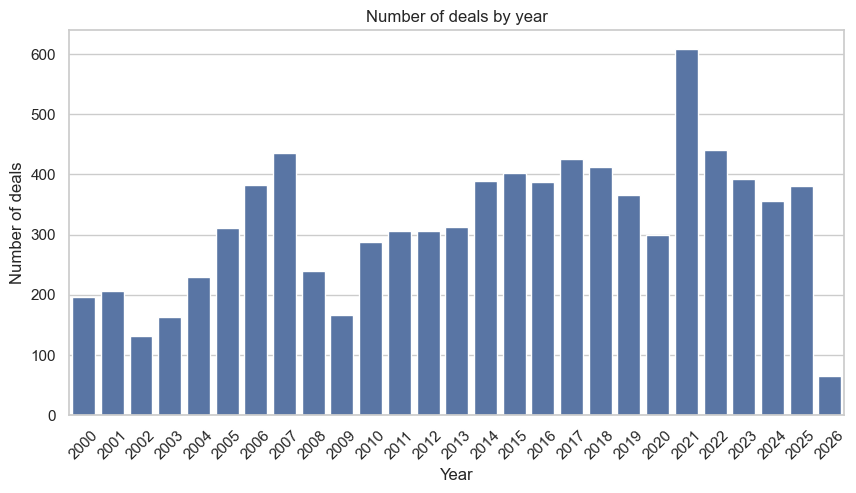

In [11]:
counts = df_gov.groupby("year").size().reset_index(name="n_deals").sort_values("year")

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=counts, x=counts["year"].astype(int).astype(str), y="n_deals")
ax.set_xlabel("Year")
ax.set_ylabel("Number of deals")
ax.set_title("Number of deals by year")
_ = plt.xticks(rotation=45)


#### 3. Number of deals by year (stacked by deal type)

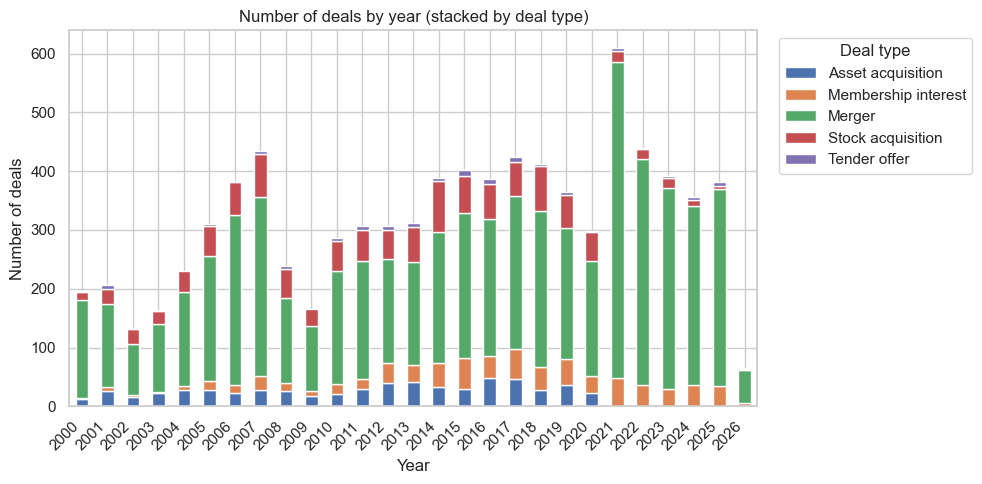

In [12]:
counts = (
    df_gov.groupby(["year", "deal_type"])
      .size()
      .reset_index(name="n_deals")
)

wide = (
    counts.pivot(index="year", columns="deal_type", values="n_deals")
          .fillna(0)
          .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
wide.plot(kind="bar", stacked=True, ax=ax)

ax.set_xlabel("Year")
ax.set_ylabel("Number of deals")
ax.set_title("Number of deals by year (stacked by deal type)")
ax.set_xticklabels(wide.index.astype(int).astype(str), rotation=45, ha="right")

ax.legend(title="Deal type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


### See what states dominate governing law clauses

#### Prep #1
Map clauses to jurisdictions

In [13]:
df_gov = add_state_columns(df_gov)


In [14]:
df_gov["states"].value_counts()


states
[Delaware]                                                  4395
[New York]                                                   990
[Delaware, New York]                                         709
[Texas]                                                      268
[Maryland]                                                   166
[California]                                                 146
[Pennsylvania]                                                93
[Canada]                                                      83
[Massachusetts]                                               66
[Nevada]                                                      59
[Delaware, Maryland]                                          57
[California, Delaware]                                        55
[Ohio]                                                        54
[Florida]                                                     50
[N/A]                                                         46
[Illinois]        

In [15]:
df_gov[["mentions_delaware", "mentions_new_york", "only_delaware", "only_new_york"]].mean().round(3)


mentions_delaware    0.669
mentions_new_york    0.235
only_delaware        0.511
only_new_york        0.115
dtype: float64

#### Prep #2
Filter down to sections that are Governing Law clauses only, rather than Governing Law + Forum Selection + ..., or else that have selected only a single state

In [16]:
taxonomy_lookup = fetch_taxonomy_lookup(session, API_BASE_URL)


In [17]:
df_gov = add_taxonomy_text_columns(df_gov, taxonomy_lookup)


In [18]:
df_gov["standard_id_text"].value_counts().head(9)


standard_id_text
Governing Law                                                                                                                                      5437
Governing Law | Forum Selection / Venue; Submission to Jurisdiction                                                                                1625
Governing Law | Forum Selection / Venue; Submission to Jurisdiction | Waiver of Jury Trial                                                         1118
Governing Law | Waiver of Jury Trial                                                                                                                131
Governing Law | Forum Selection / Venue; Submission to Jurisdiction | Waiver of Jury Trial | Specific Performance; Injunction; Equitable Relief     109
Governing Law | Forum Selection / Venue; Submission to Jurisdiction | Specific Performance; Injunction; Equitable Relief                             53
Governing Law | Waiver of Jury Trial | Forum Selection / Venue; Submiss

In [19]:
df_gov["eligible"] = df_gov.apply(
    lambda row: is_clause_family_eligible(row["standard_id"], row["states"], GOV_LAW_CLAUSE_TYPE_ID),
    axis=1,
)
df_gov["gov_law_only"] = df_gov["standard_id"].apply(
    lambda value: is_clause_family_only(value, GOV_LAW_CLAUSE_TYPE_ID)
)

df_gov[df_gov["eligible"]].shape


(7698, 26)

In [20]:
df_gov_eligible = df_gov[df_gov["eligible"]].copy()
df_gov_only = df_gov[df_gov["gov_law_only"]].copy()

print({"eligible": df_gov_eligible.shape, "gov_only": df_gov_only.shape})


{'eligible': (7698, 26), 'gov_only': (5437, 26)}


#### 1. What kinds of deals have multiple states in their governing law clauses?

In [21]:
df_gov_eligible["states"].value_counts()


states
[Delaware]                                4395
[New York]                                 990
[Delaware, New York]                       297
[Texas]                                    268
[Maryland]                                 166
[California]                               146
[Pennsylvania]                              93
[Canada]                                    83
[Massachusetts]                             66
[Nevada]                                    59
[Ohio]                                      54
[Florida]                                   50
[N/A]                                       46
[Illinois]                                  43
[Virginia]                                  40
[California, Delaware]                      33
[Washington]                                28
[North Carolina]                            28
[New Jersey]                                26
[Delaware, Maryland]                        25
[Tennessee]                                 25
[India

In [22]:
df_gov_eligible["mult"] = df_gov_eligible["states"].apply(lambda x: len(x) >= 2)


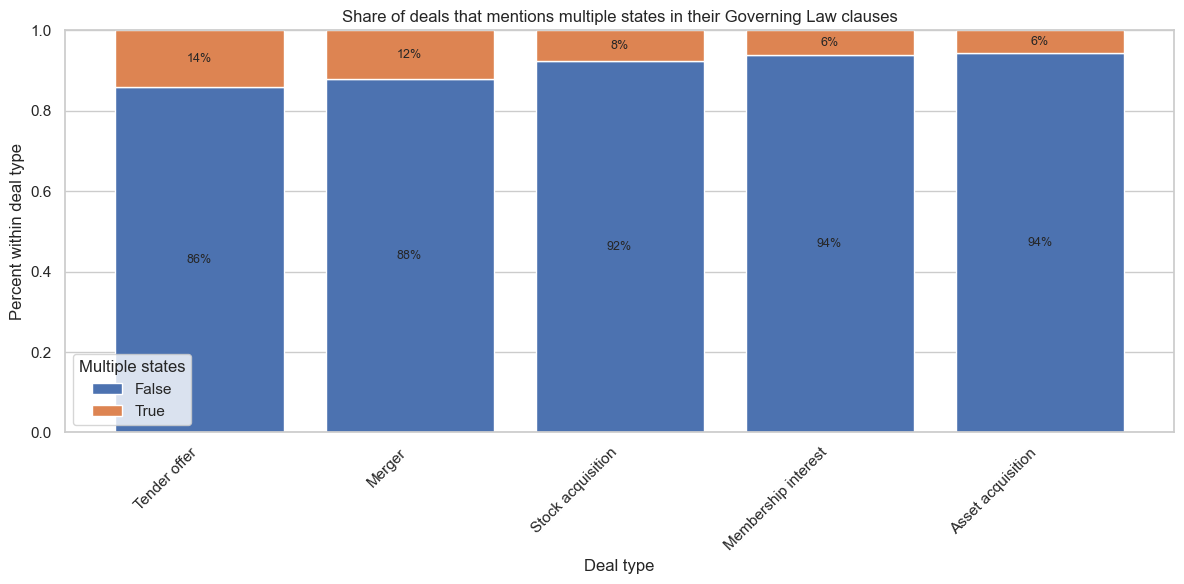

In [23]:
# Keep only usable rows
plot_df = df_gov_eligible.dropna(subset=["mult", "deal_type"]).copy()

# Ensure mult is numeric 0/1
plot_df["mult"] = pd.to_numeric(plot_df["mult"], errors="coerce")
plot_df = plot_df[plot_df["mult"].isin([0, 1])]

counts = (
    plot_df.groupby(["deal_type", "mult"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1], fill_value=0)
)

shares = counts.div(counts.sum(axis=1), axis=0).sort_values(by=1, ascending=False)

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(shares))
bars0 = ax.bar(x, shares[0], label="False")
bars1 = ax.bar(x, shares[1], bottom=shares[0], label="True")

ax.set_xticks(list(x))
ax.set_xticklabels(shares.index, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.set_xlabel("Deal type")
ax.set_ylabel("Percent within deal type")
ax.set_title("Share of deals that mentions multiple states in their Governing Law clauses")
ax.legend(title="Multiple states")

# Optional labels inside bars
for i, (v0, v1) in enumerate(zip(shares[0], shares[1])):
    if v0 > 0.05:
        ax.text(i, v0 / 2, f"{v0:.0%}", ha="center", va="center", fontsize=9)
    if v1 > 0.05:
        ax.text(i, v0 + v1 / 2, f"{v1:.0%}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
mult = df_gov_eligible[df_gov_eligible["mult"]]


In [25]:
mult['states'].value_counts()

states
[Delaware, New York]                      297
[California, Delaware]                     33
[Delaware, Maryland]                       25
[British, Canada]                          15
[Nevada, New York]                         13
[Delaware, Nevada]                         13
[Delaware, Florida]                        13
[Delaware, Texas]                          13
[Delaware, Illinois]                       11
[Maryland, New York]                       10
[British, Delaware]                         9
[Delaware, Pennsylvania]                    9
[Delaware, Washington]                      9
[Delaware, Minnesota]                       9
[Delaware, Ohio]                            8
[New York, Texas]                           8
[Delaware, Israel]                          8
[Canada, New York]                          6
[California, New York]                      6
[Delaware, Michigan]                        6
[Delaware, Oregon]                          5
[Delaware, Luxembourg]     

In [26]:
df_gov_eligible["has_debt"] = df_gov_eligible["xml"].str.lower().str.contains("debt")
df_gov_eligible["has_financing"] = df_gov_eligible["xml"].str.lower().str.contains("financ")


In [27]:
ny_de = df_gov_eligible[df_gov_eligible["mentions_new_york"] & df_gov_eligible["mentions_delaware"]].shape[0]


In [28]:
df_gov_eligible[~df_gov_eligible["has_debt"] & ~df_gov_eligible["has_financing"] & df_gov_eligible["mult"] & df_gov_eligible["mentions_new_york"] & df_gov_eligible["mentions_delaware"]].sample(n=1)[["xml", "section_uuid"]].values[0]


array(['\n        <text>This Agreement shall be governed by, construed and enforced in accordance with the Laws of the State of New York without regard to the conflict of laws principles thereof, provided, however, that to the extent that the laws of the State of Delaware are required to apply with respect to the Merger or any other actions hereunder, the laws of the State of Delaware shall so apply, without regard to the conflict of laws principles thereof. All Actions arising out of or relating to this Agreement shall be heard and determined exclusively in any state or federal court located in New York, New York (or in any appellate court therefrom) (the “Specified Courts”). Each Party hereto hereby (a) submits to the exclusive jurisdiction of any Specified Court for the purpose of any Action arising out of or relating to this Agreement brought by any Party hereto and (b) irrevocably waives, and agrees not to assert by way of motion, defense or otherwise, in any such Action, any clai

#### 2. State mentions over time (all deals)
- **Chart:** How often governing law clauses _mention_ New York or Delaware; clauses that mention both will count towards both metrics.
- **Limits:** Mentions are regex-derived and can include non-governing-law references.

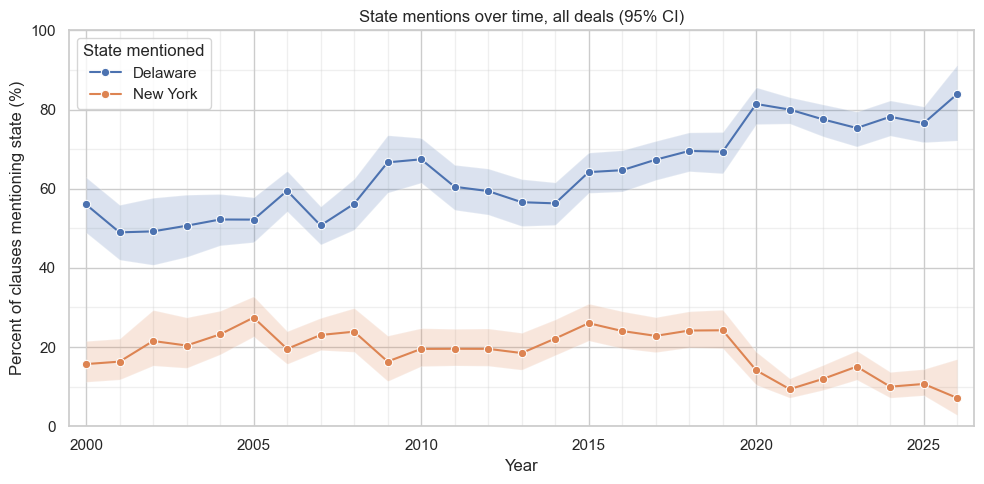

In [29]:
# Build one row per clause-state outcome and year
long_df = (
    df_gov_eligible.dropna(subset=["year"])
      .assign(year=lambda d: d["year"].astype(int))
      .melt(
          id_vars=["year"],
          value_vars=["mentions_delaware", "mentions_new_york"],
          var_name="state",
          value_name="y",
      )
)

# Aggregate yearly successes (k) and sample sizes (n)
plot_df = (
    long_df.groupby(["year", "state"], as_index=False)
           .agg(k=("y", "sum"), n=("y", "size"))
)

lo, hi = wilson_ci(plot_df["k"], plot_df["n"])
plot_df["pct"] = (plot_df["k"] / plot_df["n"]) * 100
plot_df["lo"] = lo * 100
plot_df["hi"] = hi * 100

plot_df["state"] = plot_df["state"].map({
    "mentions_delaware": "Delaware",
    "mentions_new_york": "New York",
})

# Plot yearly rates with 95% Wilson confidence bands
plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_df, x="year", y="pct", hue="state", marker="o")

ax = plt.gca()
for state, sdf in plot_df.sort_values("year").groupby("state"):
    ax.fill_between(sdf["year"].to_numpy(), sdf["lo"].to_numpy(), sdf["hi"].to_numpy(), alpha=0.2)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Percent of clauses mentioning state (%)")
plt.title("State mentions over time, all deals (95% CI)")
plt.ylim(0, 100)
x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
plt.xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

ax.legend(title="State mentioned")

plt.tight_layout()
plt.show()


#### 3. Single-state selections over time (all deals)
- **Chart:** How often governing law clauses contain _only_ New York or Delaware..  
- **Limits:** Multi-state or more complex formulations are excluded from the numerator.

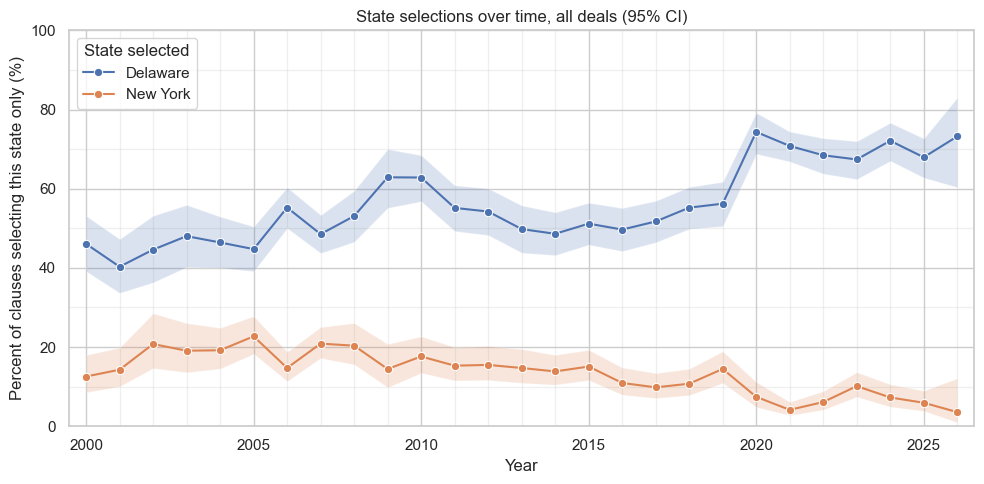

In [30]:
# Build one row per clause-state outcome and year
long_df = (
    df_gov_eligible.dropna(subset=["year"])
      .assign(year=lambda d: d["year"].astype(int))
      .melt(
          id_vars=["year"],
          value_vars=["only_delaware", "only_new_york"],
          var_name="state",
          value_name="y",
      )
)

# Aggregate yearly successes (k) and sample sizes (n)
plot_df = (
    long_df.groupby(["year", "state"], as_index=False)
           .agg(k=("y", "sum"), n=("y", "size"))
)

lo, hi = wilson_ci(plot_df["k"], plot_df["n"])
plot_df["pct"] = (plot_df["k"] / plot_df["n"]) * 100
plot_df["lo"] = lo * 100
plot_df["hi"] = hi * 100

plot_df["state"] = plot_df["state"].map({
    "only_delaware": "Delaware",
    "only_new_york": "New York",
})

# Plot yearly rates with 95% Wilson confidence bands
plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_df, x="year", y="pct", hue="state", marker="o")

ax = plt.gca()
for state, sdf in plot_df.sort_values("year").groupby("state"):
    ax.fill_between(sdf["year"].to_numpy(), sdf["lo"].to_numpy(), sdf["hi"].to_numpy(), alpha=0.2)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Percent of clauses selecting this state only (%)")
plt.title("State selections over time, all deals (95% CI)")
plt.ylim(0, 100)
x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
plt.xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

ax.legend(title="State selected")

plt.tight_layout()
plt.show()


#### 4. Single-state selections over time (mergers only)

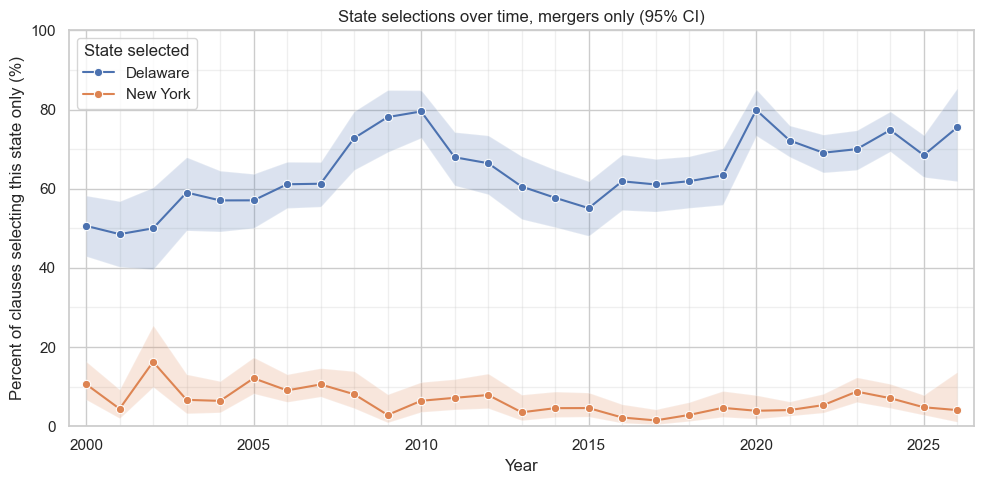

In [31]:
# Build one row per clause-state outcome and year
long_df = (
    df_gov_eligible.query('deal_type == "Merger"')
      .dropna(subset=["year"])
      .assign(year=lambda d: d["year"].astype(int))
      .melt(
          id_vars=["year"],
          value_vars=["only_delaware", "only_new_york"],
          var_name="state",
          value_name="y",
      )
)

# Aggregate yearly successes (k) and sample sizes (n)
plot_df = (
    long_df.groupby(["year", "state"], as_index=False)
           .agg(k=("y", "sum"), n=("y", "size"))
)

lo, hi = wilson_ci(plot_df["k"], plot_df["n"])
plot_df["pct"] = (plot_df["k"] / plot_df["n"]) * 100
plot_df["lo"] = lo * 100
plot_df["hi"] = hi * 100

plot_df["state"] = plot_df["state"].map({
    "only_delaware": "Delaware",
    "only_new_york": "New York",
})

# Plot yearly rates with 95% Wilson confidence bands
plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_df, x="year", y="pct", hue="state", marker="o")

ax = plt.gca()
for state, sdf in plot_df.sort_values("year").groupby("state"):
    ax.fill_between(sdf["year"].to_numpy(), sdf["lo"].to_numpy(), sdf["hi"].to_numpy(), alpha=0.2)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Percent of clauses selecting this state only (%)")
plt.title("State selections over time, mergers only (95% CI)")
plt.ylim(0, 100)
x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
plt.xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

ax.legend(title="State selected")

plt.tight_layout()
plt.show()


#### 5. 100% Stacked jurisdictions by time

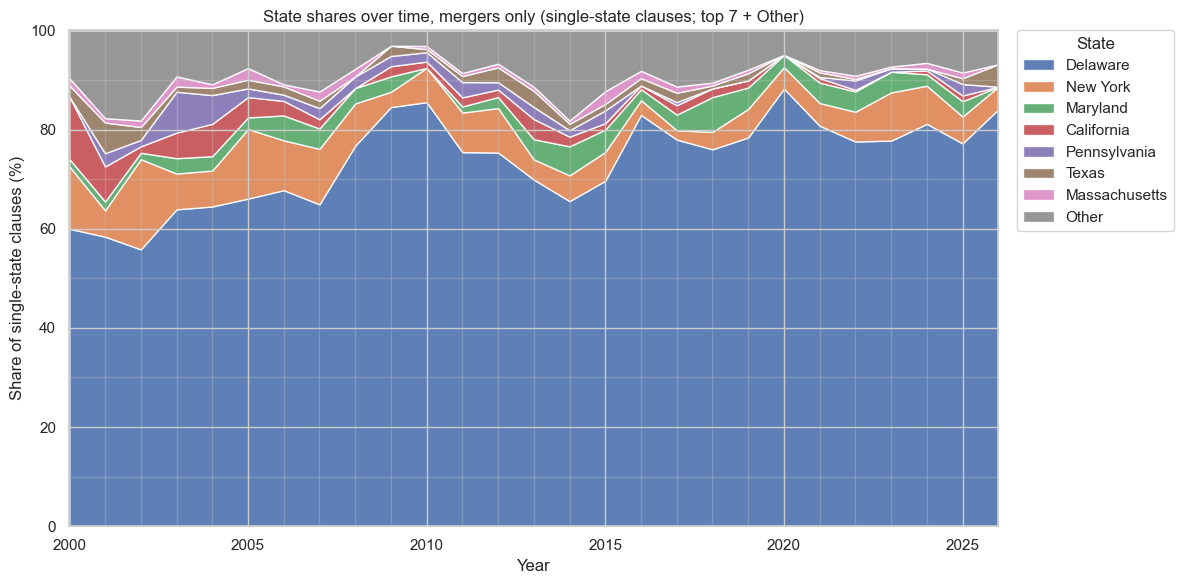

In [32]:
# Keep only mergers with exactly one selected state
plot_base = (
    df_gov_eligible.query('deal_type == "Merger"')
      .dropna(subset=["year", "states"])
      .loc[
          lambda d: d["states"].apply(
              lambda xs: isinstance(xs, list) and len(xs) == 1 and xs[0] not in [None, "", "N/A"]
          )
      ]
      .assign(
          year=lambda d: d["year"].astype(int),
          state=lambda d: d["states"].str[0],
      )
      .copy()
)

if plot_base.empty:
    raise RuntimeError("No merger rows found with exactly one valid state in `states`.")

# Top 10 states overall; everything else becomes Other
top_states = plot_base["state"].value_counts().head(7).index.tolist()
plot_base["state_plot"] = np.where(plot_base["state"].isin(top_states), plot_base["state"], "Other")

# Count by year/state bucket, then convert to within-year shares
plot_df = (
    plot_base.groupby(["year", "state_plot"], as_index=False)
             .size()
             .rename(columns={"size": "n"})
)

plot_df["share"] = (
    plot_df["n"] / plot_df.groupby("year")["n"].transform("sum") * 100
)

# Keep legend/order stable: top states by overall frequency, then Other last
state_order = top_states + (["Other"] if (plot_base["state_plot"] == "Other").any() else [])

wide = (
    plot_df.pivot(index="year", columns="state_plot", values="share")
           .reindex(columns=state_order)
           .fillna(0)
           .sort_index()
)

# Plot as a 100% stacked area chart over time
plt.figure(figsize=(12, 6))
ax = plt.gca()

x = wide.index.to_numpy()
y_arrays = [wide[col].to_numpy() for col in wide.columns]

ax.stackplot(x, y_arrays, labels=wide.columns, alpha=0.9)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
ax.set_xlabel("Year")
ax.set_ylabel("Share of single-state clauses (%)")
ax.set_title("State shares over time, mergers only (single-state clauses; top 7 + Other)")
ax.set_ylim(0, 100)

x_min, x_max = wide.index.min(), wide.index.max()
ax.set_xlim(x_min, x_max)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

ax.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.set_axisbelow(False)

plt.tight_layout()
plt.show()


### See how the length of governing law clauses has evolved over time

In [33]:
xml_text = xml_to_text(df_gov_only["xml"])
df_gov_only["word_count"] = xml_text.str.split().str.len()


In [34]:
# Check for short outliers
short = df_gov_only.sort_values(by="word_count", ascending=True).head(5)["xml"].tolist()

for item in short:
    print(item)
    print()
    print("#" * 40)
    print()



        <text>This Agreement is subject to Swiss Law, excluding the CISG.</text>
      

########################################


        <text>This Agreement shall be governed by the laws of State of New York.</text>
      

########################################


        <text>This Agreement shall be governed by and construed in accordance with Belgian law.</text>
      

########################################


        <text>This Agreement shall be governed by and construed in accordance with French law.</text>
      

########################################


        <text>This Agreement shall be governed and interpreted in accordance with the Federal Laws of Mexico.</text>
      

########################################



In [35]:
# Check for long outliers
long = df_gov_only.sort_values(by="word_count", ascending=False).head(5)["xml"].tolist()

for item in long:
    print(item)
    print()
    print("#" * 40)
    print()



        <text>(a) Any controversy or claim arising out of or relating to this Agreement or the transactions contemplated hereunder or a breach thereof (each, a “Dispute”) shall be resolved by binding and confidential arbitration. Parent, on the one hand, and the Company Shareholders and MJM, on the other hand, may initiate arbitration under this Section 12.07 by filing a written arbitration demand with the regional office of the American Arbitration Association (“AAA”) closest to Warren, Michigan and contemporaneously providing a copy of such demand to the other party at the applicable address(es) provided in Section 12.02. The arbitration shall be governed by and conducted pursuant to the AAA’s Commercial Arbitration Rules, including the Procedures for Large, Complex Commercial Disputes and the Optional Rules for Emergency Measures of Protection; provided, however, there shall be three arbitrators. One arbitrator will be selected by each of Parent, on the one hand, and the Company St

#### 1. Word count scatter over time (mergers only)
- **Chart:** Clause length spans orders of magnitudes, so we use a log scale to enable comparisons.  
- **Limits:** Word count is descriptive and does not measure legal complexity directly.

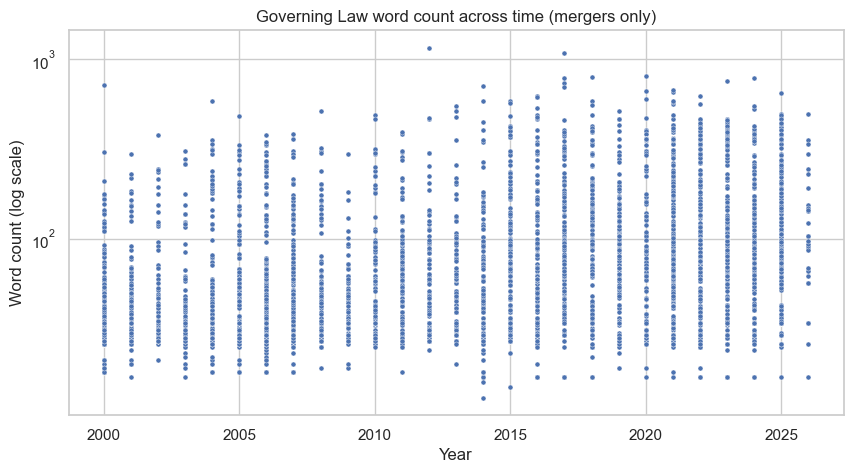

In [36]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_gov_only[df_gov_only["deal_type"] == "Merger"], x="year", y="word_count", s=13)
plt.yscale("log")
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Word count (log scale)")
_ = plt.title("Governing Law word count across time (mergers only)")


#### 2. Word count distribution by year (mergers only)
- **Chart:** Violin widths summarize how the full clause-length distribution changes year to year.  
- **Limits:** Years with small sample sizes can look irregular.

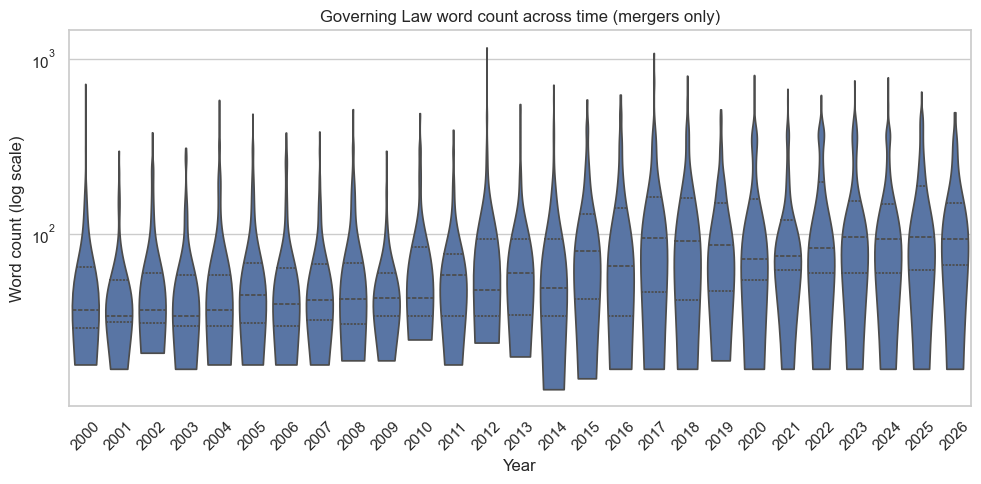

In [37]:
years = np.sort(df_gov_only["year"].astype(int).unique())
df_gov_only["year_cat"] = pd.Categorical(df_gov_only["year"].astype(int), categories=years, ordered=True)

plt.figure(figsize=(10, 5))
ax = sns.violinplot(data=df_gov_only[df_gov_only["deal_type"] == "Merger"], x="year_cat", y="word_count", cut=0, inner="quartile", density_norm="width")
plt.yscale("log")

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=45)

ax.set_xlabel("Year")
ax.set_ylabel("Word count (log scale)")
ax.set_title("Governing Law word count across time (mergers only)")
plt.tight_layout()


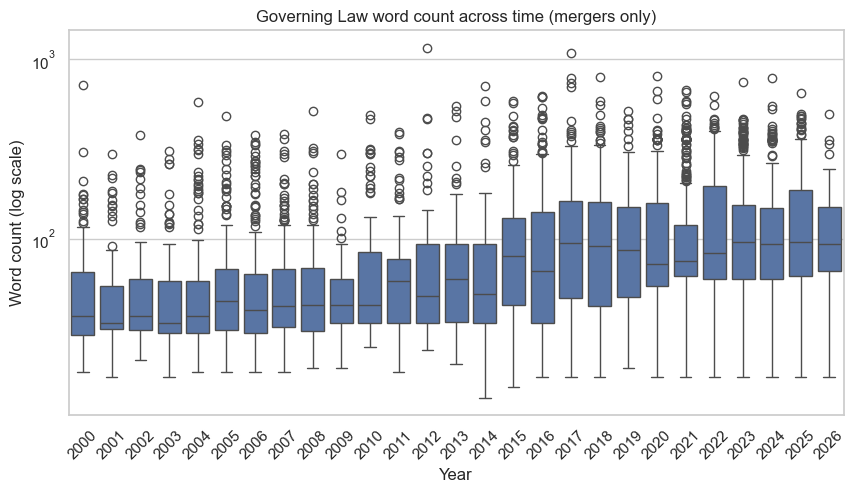

In [38]:
years = np.sort(df_gov_only["year"].astype(int).unique())
df_gov_only["year_cat"] = pd.Categorical(df_gov_only["year"].astype(int), categories=years, ordered=True)

plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=df_gov_only[df_gov_only["deal_type"] == "Merger"], x="year_cat", y="word_count")
plt.yscale("log")

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=45)

ax.set_xlabel("Year")
ax.set_ylabel("Word count (log scale)")
_ = ax.set_title("Governing Law word count across time (mergers only)")


### See how choice of law and length vary with deal type

#### 1. Single-state choice by deal type
- **Chart:** Error bars represent the 95% confidence interval.  

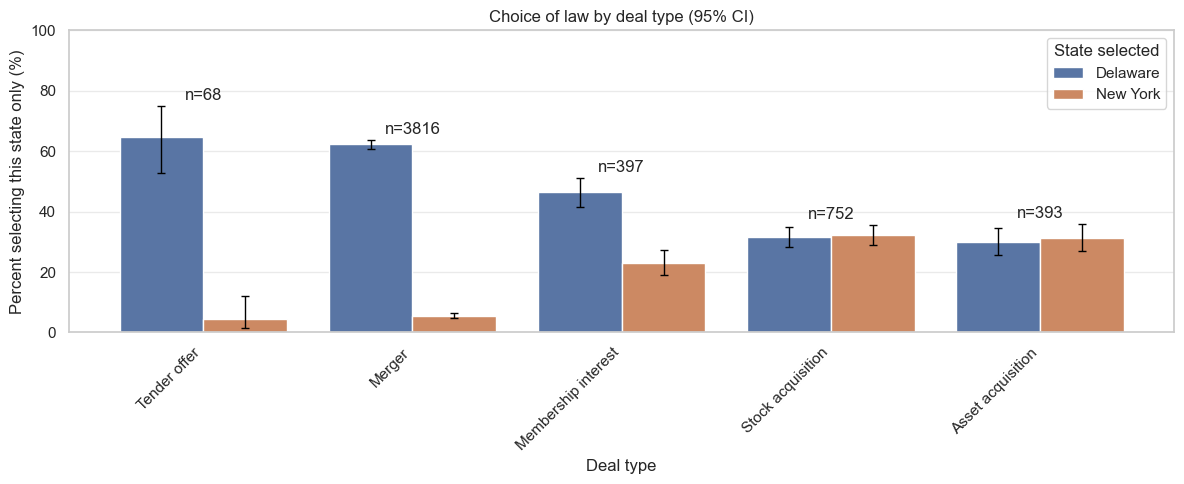

In [39]:
# Build one row per clause-state outcome and deal type
long_df = (
    df_gov_only.dropna(subset=["deal_type"])
      .melt(
          id_vars=["deal_type"],
          value_vars=["only_delaware", "only_new_york"],
          var_name="state",
          value_name="y",
      )
)

# Aggregate successes (k) and sample sizes (n) by deal type and state
plot_df = (
    long_df.groupby(["deal_type", "state"], as_index=False)
           .agg(k=("y", "sum"), n=("y", "size"))
)

# Compute percentages with 95% Wilson confidence intervals
lo, hi = wilson_ci(plot_df["k"], plot_df["n"])
plot_df["pct"] = (plot_df["k"] / plot_df["n"]) * 100
plot_df["lo"]  = lo * 100
plot_df["hi"]  = hi * 100

plot_df["state"] = plot_df["state"].map({
    "only_delaware": "Delaware",
    "only_new_york": "New York",
})

# Order deal types by Delaware-only share
order = (
    plot_df.query("state == 'Delaware'")
           .sort_values("pct", ascending=False)["deal_type"]
           .tolist()
)

# Plot side-by-side bars for Delaware vs New York
plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=plot_df,
    x="deal_type",
    y="pct",
    hue="state",
    order=order,
    errorbar=None,   # Draw custom confidence intervals
)

# Add Wilson confidence intervals aligned to bar positions
for container, state in zip(ax.containers, ["Delaware", "New York"]):
    sdf = plot_df[plot_df["state"] == state].set_index("deal_type").loc[order].reset_index()
    xs = [p.get_x() + p.get_width()/2 for p in container.patches]
    y = sdf["pct"].to_numpy()
    yerr = np.vstack([y - sdf["lo"].to_numpy(), sdf["hi"].to_numpy() - y])
    ax.errorbar(xs, y, yerr=yerr, fmt="none", capsize=3, linewidth=1, ecolor="black")

# Label each deal type with n above the larger confidence interval
pad = 1.0  # Padding above the confidence interval (percentage points)
g = (plot_df.set_index(["deal_type", "state"])
              .loc[(order, ["Delaware", "New York"]), ["n", "hi"]]
              .reset_index())

xticks = ax.get_xticks()
xmap = dict(zip(order, xticks))

for dt in order:
    sub = g[g["deal_type"] == dt]
    n = int(sub["n"].iloc[0])
    y_text = float(sub["hi"].max()) + pad
    ax.text(xmap[dt], y_text, f"n={n}", ha="center", va="bottom")

ax.set_xlabel("Deal type")
ax.set_ylabel("Percent selecting this state only (%)")
ax.set_title("Choice of law by deal type (95% CI)")
ax.set_ylim(0, 100)

ax.grid(True, axis="y", which="major", alpha=0.4)

ax.legend(title="State selected")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#### 2. Word count by deal type

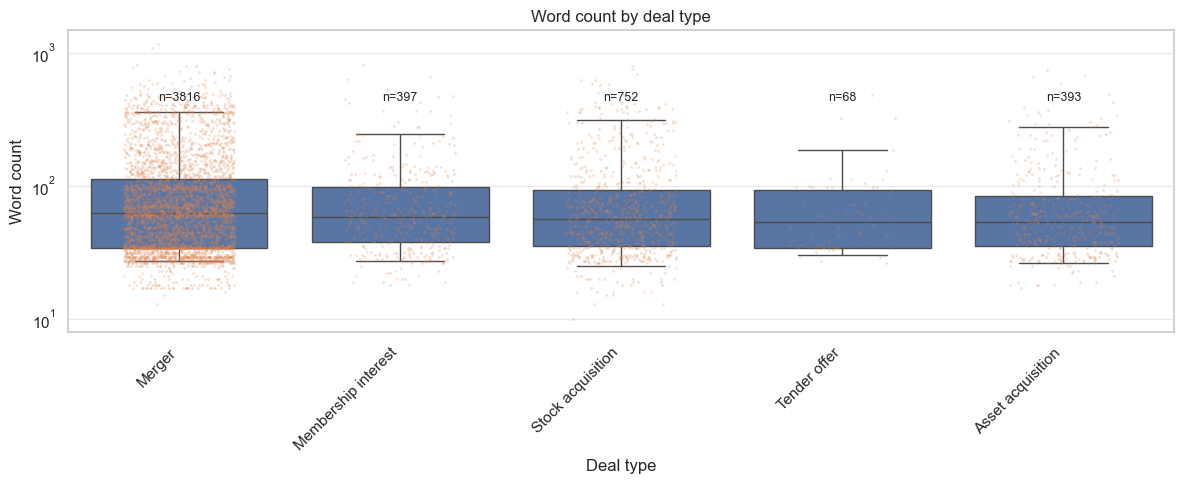

In [40]:
# Plot word-count distribution by deal type
plot_df = df_gov_only.dropna(subset=["deal_type", "word_count"]).copy()

# Order deal types by median word count (descending)
order = (
    plot_df.groupby("deal_type")["word_count"]
           .median()
           .sort_values(ascending=False)
           .index
           .tolist()
)

plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=plot_df,
    x="deal_type",
    y="word_count",
    order=order,
    showfliers=False,      # Hide outliers for readability
    whis=(5, 95),          # Use 5th-95th percentile whiskers
)

# Overlay jittered points to show distribution texture
sns.stripplot(
    data=plot_df,
    x="deal_type",
    y="word_count",
    order=order,
    size=2,
    alpha=0.25,
    jitter=0.25,
    ax=ax,
)

# Label each deal type with n
counts = plot_df["deal_type"].value_counts().reindex(order)
ymax = plot_df["word_count"].quantile(0.975)
for i, dt in enumerate(order):
    ax.text(i, ymax*1.02, f"n={int(counts.loc[dt])}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Deal type")
ax.set_ylabel("Word count")
ax.set_title("Word count by deal type")
ax.grid(True, axis="y", which="major", alpha=0.4)
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Bayesian comparison: Is Delaware more common than New York by deal type?

Estimate posterior distributions for `P(only_delaware)` and `P(only_new_york)` with a Beta(1,1) prior, then compute `Pr(p_delaware > p_new_york)` for each deal type.

**Chart:** Values near 100% indicate strong posterior support that Delaware-only is more common than New York-only for that deal type.  
**Limits:** This compares single-state selections only and assumes independent Bernoulli observations within deal type.

,deal_type,n,Pr(Delaware > New York),E[p_delaware],E[p_new_york]
0,Membership interest,397,100.00,46.37,23.04
1,Merger,3816,100.00,62.28,5.61
2,Tender offer,68,100.00,64.23,5.67
3,Stock acquisition,752,41.30,31.70,32.24
4,Asset acquisition,393,34.26,30.10,31.42


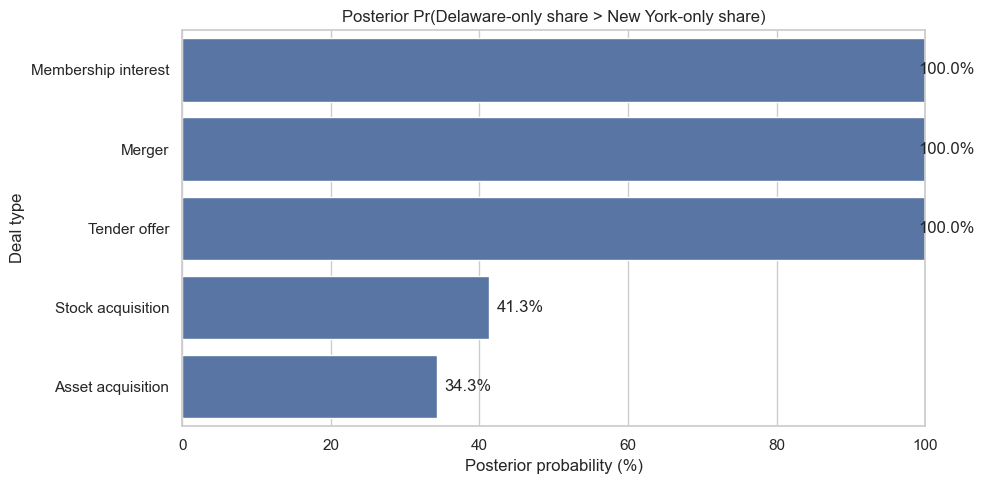

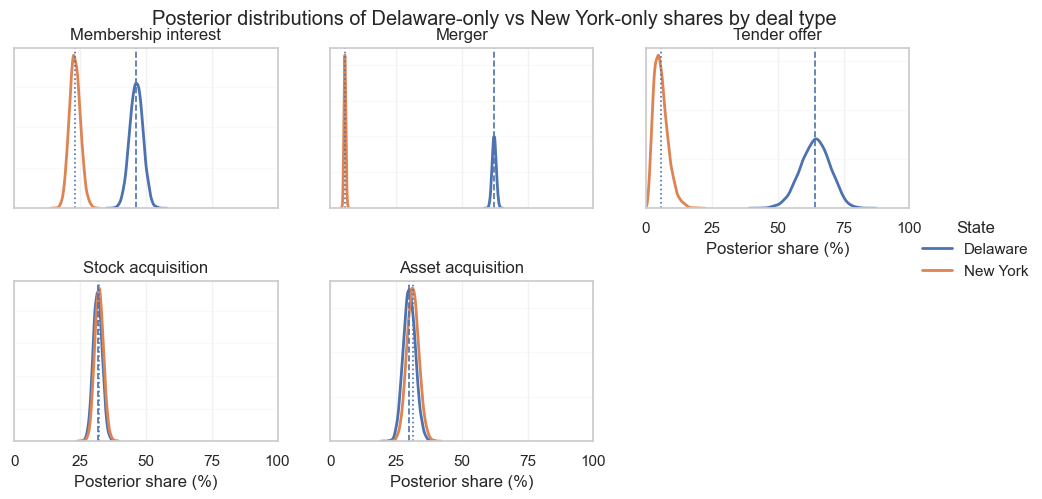

In [41]:
rng = np.random.default_rng(7)
draws = 20_000

rows = []
posterior_rows = []  # Store posterior draws for facet plotting

for deal_type, g in df_gov_only.dropna(subset=["deal_type"]).groupby("deal_type"):
    n = len(g)
    k_delaware = int(g["only_delaware"].sum())
    k_new_york = int(g["only_new_york"].sum())

    # Use Beta(1,1) prior -> Beta(1+k, 1+n-k) posterior.
    delaware_draws = rng.beta(1 + k_delaware, 1 + n - k_delaware, size=draws)
    new_york_draws = rng.beta(1 + k_new_york, 1 + n - k_new_york, size=draws)

    # Store summary metrics.
    rows.append({
        "deal_type": deal_type,
        "n": n,
        "Pr(Delaware > New York)": float((delaware_draws > new_york_draws).mean()),
        "E[p_delaware]": float(delaware_draws.mean()),
        "E[p_new_york]": float(new_york_draws.mean()),
        "delaware_lo": float(np.quantile(delaware_draws, 0.025)),
        "delaware_hi": float(np.quantile(delaware_draws, 0.975)),
        "new_york_lo": float(np.quantile(new_york_draws, 0.025)),
        "new_york_hi": float(np.quantile(new_york_draws, 0.975)),
    })

    # Store posterior draws as percentages for plotting
    posterior_rows.append(pd.DataFrame({
        "deal_type": deal_type,
        "state": "Delaware",
        "p": delaware_draws * 100
    }))
    posterior_rows.append(pd.DataFrame({
        "deal_type": deal_type,
        "state": "New York",
        "p": new_york_draws * 100
    }))

bayes_df = pd.DataFrame(rows).sort_values("Pr(Delaware > New York)", ascending=False).reset_index(drop=True)
posterior_df = pd.concat(posterior_rows, ignore_index=True)

# Convert selected summary columns to percentages
pct_cols = ["Pr(Delaware > New York)", "E[p_delaware]", "E[p_new_york]",
            "delaware_lo", "delaware_hi", "new_york_lo", "new_york_hi"]
bayes_df[pct_cols] = bayes_df[pct_cols] * 100

# Keep facet order consistent with the summary table
deal_order = bayes_df["deal_type"].tolist()
posterior_df["deal_type"] = pd.Categorical(posterior_df["deal_type"], categories=deal_order, ordered=True)

display(
    bayes_df[["deal_type", "n", "Pr(Delaware > New York)", "E[p_delaware]", "E[p_new_york]"]].round(2)
)

# Plot posterior probability bar chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=bayes_df, x="Pr(Delaware > New York)", y="deal_type")
ax.set_xlabel("Posterior probability (%)")
ax.set_ylabel("Deal type")
ax.set_title("Posterior Pr(Delaware-only share > New York-only share)")
ax.set_xlim(0, 100)

for patch in ax.patches:
    width = patch.get_width()
    ax.text(min(width + 1, 99), patch.get_y() + patch.get_height() / 2, f"{width:.1f}%", va="center")

plt.tight_layout()
plt.show()

g = sns.FacetGrid(
    posterior_df,
    col="deal_type",
    col_wrap=3,
    hue="state",
    sharex=True,
    sharey=False,
    height=2.4,
    aspect=1.35,
    margin_titles=False,
    despine=False,
)

g.map_dataframe(
    sns.kdeplot,
    x="p",
    fill=False,
    common_norm=False,
    bw_adjust=1.1,
    clip=(0, 100),
    linewidth=2
)

g.set_titles("{col_name}")

for ax, deal_type in zip(g.axes.flat, deal_order):
    sub = bayes_df.loc[bayes_df["deal_type"] == deal_type].iloc[0]
    ax.axvline(sub["E[p_delaware]"], linestyle="--", linewidth=1.2)
    ax.axvline(sub["E[p_new_york]"], linestyle=":", linewidth=1.2)
    ax.set_xlim(0, 100)
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", alpha=0.10)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_yticklabels([])

g.add_legend(title="State")
g.set_xlabels("Posterior share (%)")
g.set_ylabels("")
g.fig.subplots_adjust(
    top=0.90,
    bottom=0.08,
    left=0.06,
    right=0.88,
    hspace=0.45,
    wspace=0.20
)
g.fig.suptitle("Posterior distributions of Delaware-only vs New York-only shares by deal type")

plt.show()


### Concentration of governing-law selections over time (mergers only)

Compute annual concentration metrics on clauses with a single identified jurisdiction: Herfindahl index (HHI), Shannon entropy, and effective number of states (`1/HHI`).

#### 1. Straight HHI, no statistical tricks

,year,n,hhi,entropy,effective_states
17,2017,96,0.615,1.070,1.627
18,2018,87,0.581,1.138,1.720
19,2019,89,0.659,0.935,1.518
20,2020,117,0.869,0.344,1.150
21,2021,298,0.724,0.788,1.381
22,2022,191,0.697,0.861,1.435
23,2023,183,0.697,0.757,1.435
24,2024,164,0.712,0.782,1.404
25,2025,143,0.641,0.983,1.559
26,2026,26,0.725,0.589,1.380


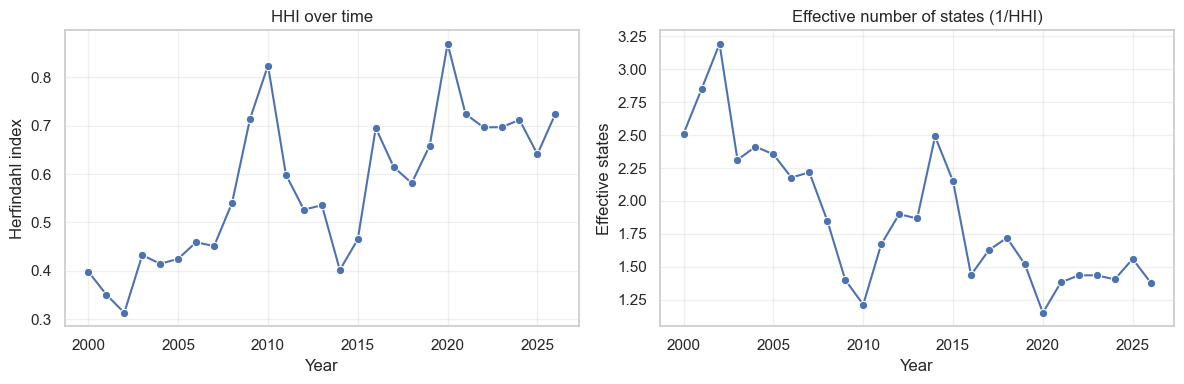

In [42]:
single_state_df = df_gov_only[
    df_gov_only["states"].apply(lambda xs: isinstance(xs, list) and len(xs) == 1 and xs[0] != "N/A")
].copy()
single_state_df["state"] = single_state_df["states"].str[0]
single_state_df["year"] = single_state_df["year"].astype(int)
single_state_df = single_state_df[single_state_df["deal_type"] == "Merger"]

concentration_rows = []
for year, g in single_state_df.groupby("year"):
    shares = g["state"].value_counts(normalize=True)
    hhi = float((shares ** 2).sum())
    entropy = float(-(shares * np.log(shares)).sum())
    concentration_rows.append({
        "year": year,
        "n": int(len(g)),
        "hhi": hhi,
        "entropy": entropy,
        "effective_states": float(1 / hhi),
    })

conc_df = pd.DataFrame(concentration_rows).sort_values("year")
display(conc_df.round(3).tail(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

sns.lineplot(data=conc_df, x="year", y="hhi", marker="o", ax=axes[0])
axes[0].set_title("HHI over time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Herfindahl index")

sns.lineplot(data=conc_df, x="year", y="effective_states", marker="o", ax=axes[1])
axes[1].set_title("Effective number of states (1/HHI)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Effective states")

for ax in axes:
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
    ax.grid(True, axis="both", alpha=0.3)

plt.tight_layout()
plt.show()


#### 2. HHI estimated using a Bayesian Dirichlet posterior, with a 95% credible interval

,year,n,hhi,hhi_lo,hhi_hi,entropy,entropy_lo,entropy_hi,effective_states,effective_states_lo,effective_states_hi
17,2017,96,0.302,0.221,0.391,2.240,1.939,2.535,3.384,2.559,4.523
18,2018,87,0.271,0.194,0.359,2.341,2.033,2.630,3.783,2.787,5.152
19,2019,89,0.308,0.225,0.401,2.216,1.904,2.514,3.319,2.496,4.450
20,2020,117,0.467,0.374,0.563,1.697,1.402,1.993,2.164,1.775,2.672
21,2021,298,0.553,0.486,0.619,1.404,1.204,1.609,1.815,1.616,2.059
22,2022,191,0.467,0.390,0.546,1.682,1.437,1.925,2.159,1.832,2.562
23,2023,183,0.459,0.382,0.539,1.661,1.419,1.907,2.194,1.856,2.616
24,2024,164,0.450,0.370,0.534,1.732,1.471,1.991,2.244,1.872,2.705
25,2025,143,0.384,0.305,0.467,1.941,1.676,2.209,2.637,2.144,3.280
26,2026,26,0.129,0.076,0.205,2.897,2.566,3.177,8.288,4.870,13.241


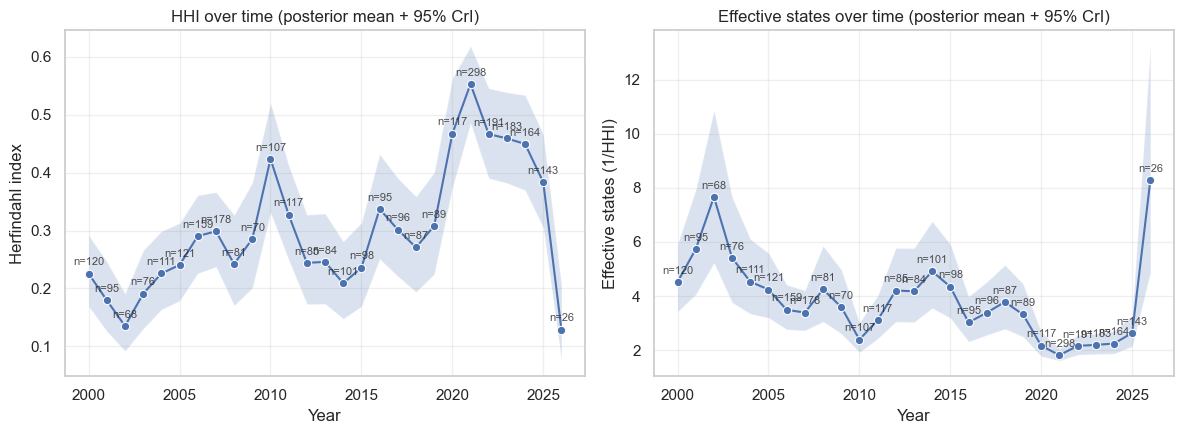

In [43]:
single_state_df = df_gov_only[
    df_gov_only["states"].apply(lambda xs: isinstance(xs, list) and len(xs) == 1 and xs[0] != "N/A")
].copy()
single_state_df["state"] = single_state_df["states"].str[0]
single_state_df["year"] = single_state_df["year"].astype(int)
single_state_df = single_state_df[single_state_df["deal_type"] == "Merger"].copy()

rng = np.random.default_rng(7)
draws = 20_000
alpha_prior = 1.0   # Symmetric Dirichlet prior (Laplace smoothing)

# Use a fixed state universe across years for comparability
state_universe = sorted(single_state_df["state"].dropna().unique().tolist())

rows = []

for year, g in single_state_df.groupby("year"):
    n = len(g)
    if n == 0:
        continue

    counts = g["state"].value_counts()

    # Align counts to the common state universe
    c = counts.reindex(state_universe, fill_value=0).to_numpy(dtype=float)
    alpha = np.full_like(c, fill_value=alpha_prior, dtype=float)

    # Draw posterior samples of the state-share vector p
    p_draws = rng.dirichlet(alpha + c, size=draws)

    # Draw posterior samples of concentration metrics
    hhi_draws = np.sum(p_draws ** 2, axis=1)
    p_safe = np.clip(p_draws, 1e-15, 1.0)
    entropy_draws = -np.sum(p_safe * np.log(p_safe), axis=1)
    effective_draws = 1.0 / hhi_draws

    rows.append({
        "year": int(year),
        "n": int(n),
        "hhi": float(hhi_draws.mean()),
        "hhi_lo": float(np.quantile(hhi_draws, 0.025)),
        "hhi_hi": float(np.quantile(hhi_draws, 0.975)),
        "entropy": float(entropy_draws.mean()),
        "entropy_lo": float(np.quantile(entropy_draws, 0.025)),
        "entropy_hi": float(np.quantile(entropy_draws, 0.975)),
        "effective_states": float(effective_draws.mean()),
        "effective_states_lo": float(np.quantile(effective_draws, 0.025)),
        "effective_states_hi": float(np.quantile(effective_draws, 0.975)),
    })

conc_df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)

display(conc_df.round(3).tail(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

sns.lineplot(data=conc_df, x="year", y="hhi", marker="o", ax=axes[0])
axes[0].fill_between(
    conc_df["year"].to_numpy(),
    conc_df["hhi_lo"].to_numpy(),
    conc_df["hhi_hi"].to_numpy(),
    alpha=0.20
)
axes[0].set_title("HHI over time (posterior mean + 95% CrI)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Herfindahl index")

sns.lineplot(data=conc_df, x="year", y="effective_states", marker="o", ax=axes[1])
axes[1].fill_between(
    conc_df["year"].to_numpy(),
    conc_df["effective_states_lo"].to_numpy(),
    conc_df["effective_states_hi"].to_numpy(),
    alpha=0.20
)
axes[1].set_title("Effective states over time (posterior mean + 95% CrI)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Effective states (1/HHI)")

for ax, ycol in zip(axes, ["hhi", "effective_states"]):
    for _, row in conc_df.iterrows():
        ax.annotate(
            f"n={int(row['n'])}",
            (row["year"], row[ycol]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=8,
            alpha=0.8
        )

for ax in axes:
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
    ax.grid(True, axis="both", alpha=0.3)

plt.tight_layout()
plt.show()


## Forum Selection

### Download
Paginate through all matching sections for clause type `f758e6a8d32690bd`, which is the taxonomy ID for Forum Selection clauses.

In [44]:
FORUM_CLAUSE_TYPE_ID = "f758e6a8d32690bd"

sections_for = download_sections_for_standard_id(
    session,
    API_BASE_URL,
    FORUM_CLAUSE_TYPE_ID,
    metadata=["deal_type"],
)


Progress: page 10/11 | sections=1000 | elapsed=22.0s
Progress: page 20/21 | sections=2000 | elapsed=35.7s
Progress: page 30/31 | sections=3000 | elapsed=49.0s
Progress: page 40/41 | sections=4000 | elapsed=62.4s
Progress: page 50/51 | sections=5000 | elapsed=75.8s
Progress: page 60/61 | sections=6000 | elapsed=89.2s
Progress: page 70/70 | sections=6926 | elapsed=102.4s
Returned sections: 6926
Access tier: api_key
Total download time: 102.4s


In [45]:
df_for = prepare_clause_df(sections_for)
df_for.head(1)


,acquirer,agreement_uuid,article_title,id,metadata,section_title,section_uuid,standard_id,target,verified,xml,year,deal_type
0,CINTAS CORPORATION,8f3084d0-f42d-5bb7-9f6a-a4a51e55a1b4,Article VIII General Provisions,7e09ebbd-fd62-5911-aa5b-c74fdbd4429c,{'deal_type': 'merger'},Section 8.11 Consent to Jurisdiction.,7e09ebbd-fd62-5911-aa5b-c74fdbd4429c,[f758e6a8d32690bd],UNIFIRST CORPORATION,False,\n <text>(a) Each of the parties hereto...,2026,Merger


In [46]:
print(df_for.shape)


(6560, 13)


In [47]:
df_for["deal_type"].value_counts(dropna=False)


deal_type
Merger                 4724
Stock acquisition       764
Membership interest     562
Asset acquisition       406
Tender offer             93
NaN                      11
Name: count, dtype: int64

In [48]:
df_for.shape


(6560, 13)

In [49]:
df_for.head()


,acquirer,agreement_uuid,article_title,id,metadata,section_title,section_uuid,standard_id,target,verified,xml,year,deal_type
0,CINTAS CORPORATION,8f3084d0-f42d-5bb7-9f6a-a4a51e55a1b4,Article VIII General Provisions,7e09ebbd-fd62-5911-aa5b-c74fdbd4429c,{'deal_type': 'merger'},Section 8.11 Consent to Jurisdiction.,7e09ebbd-fd62-5911-aa5b-c74fdbd4429c,[f758e6a8d32690bd],UNIFIRST CORPORATION,False,\n <text>(a) Each of the parties hereto...,2026,Merger
1,"Universal Health Services, Inc.",7633544b-9b1b-56f8-a0bd-7dea012fb467,ARTICLE VIII Miscellaneous,cd796e5b-059e-5f91-b899-b03ed69a0e57,{'deal_type': 'merger'},SECTION 8.07. Governing Law; Jurisdiction.,cd796e5b-059e-5f91-b899-b03ed69a0e57,"[5e59453aaa9255c4, f758e6a8d32690bd]","Talkspace, Inc.",False,\n <text>(a) This Agreement shall be go...,2026,Merger
2,Ondas Inc.,93cc5d8e-14c1-56bb-9b69-e4c097df0208,ARTICLE X GENERAL PROVISIONS,c9ca1271-6911-57b3-89d4-b2536c894834,{'deal_type': 'merger'},Section 10.10 Consent to Jurisdiction.,c9ca1271-6911-57b3-89d4-b2536c894834,[f758e6a8d32690bd],"Mistral, Inc.",False,\n <text>Each of the Parties hereto (a)...,2026,Merger
3,Aureus Greenway Holdings Inc.,3a8e1180-d3a2-5d6f-a0ba-02ce403a7182,Article VIII MISCELLANEOUS,93c13410-f807-52f7-9634-b25ad5e212c0,{'deal_type': 'merger'},Section 8.5 Submission to Jurisdiction; Service.,93c13410-f807-52f7-9634-b25ad5e212c0,[f758e6a8d32690bd],Autonomous Power Corporation,False,\n <text>Each Party (a) irrevocably and...,2026,Merger
4,Calisa Acquisition Corp,0bdd1811-aa23-5fb4-b8f1-fd2c3e41a175,ARTICLE 9 MISCELLANEOUS,6794c24b-4d2b-5ac7-a13d-ccd5c6f589dd,{'deal_type': 'merger'},Section 9.15 Submission to Jurisdiction.,6794c24b-4d2b-5ac7-a13d-ccd5c6f589dd,[f758e6a8d32690bd],Goodvision AI Inc.,False,\n <text>Each of the Parties irrevocabl...,2026,Merger


### See prevalence of forum selection clauses

#### Prep

In [50]:
page_size = 100
request_pause_s = 0.25
progress_every = 10

merger_agreements = []
cursor = None
batch_num = 0
start_time = time.time()

while True:
    params = {
        "page_size": page_size,
        "deal_type": "merger",
    }
    if cursor:
        params["cursor"] = cursor

    r = session.get(f"{API_BASE_URL}/v1/agreements", params=params, timeout=60)
    r.raise_for_status()
    payload = r.json()

    batch = payload.get("results", [])
    batch_num += 1

    for agreement in batch:
        agreement_uuid = agreement.get("agreement_uuid")
        year = agreement.get("year")

        if not isinstance(agreement_uuid, str) or not agreement_uuid:
            raise RuntimeError("Invalid agreements payload: missing agreement_uuid.")
        if year is None:
            continue

        merger_agreements.append(
            {
                "agreement_uuid": agreement_uuid,
                "year": int(year),
            }
        )

    if batch_num % progress_every == 0 or not payload.get("has_next"):
        elapsed = time.time() - start_time
        print(
            f"Progress: batch {batch_num} | batch_size={len(batch)} | merger agreements={len(merger_agreements)} | elapsed={elapsed:.1f}s"
        )

    if not payload.get("has_next"):
        break

    next_cursor = payload.get("next_cursor")
    if not isinstance(next_cursor, str) or not next_cursor:
        raise RuntimeError("Invalid agreements payload: has_next=true but next_cursor missing.")

    cursor = next_cursor
    time.sleep(request_pause_s)

elapsed_total = time.time() - start_time
print(f"Returned merger agreements: {len(merger_agreements)}")
print(f"Access tier: {payload.get('access', {}).get('tier')}")
print(f"Total download time: {elapsed_total:.1f}s")

if not merger_agreements:
    raise RuntimeError("No merger agreements returned by /v1/agreements.")

merger_agreements_df = pd.DataFrame(merger_agreements)
merger_agreements_df.head()

Progress: batch 10 | batch_size=100 | merger agreements=1000 | elapsed=4.4s
Progress: batch 20 | batch_size=100 | merger agreements=2000 | elapsed=9.0s
Progress: batch 30 | batch_size=100 | merger agreements=3000 | elapsed=13.7s
Progress: batch 40 | batch_size=100 | merger agreements=4000 | elapsed=18.5s
Progress: batch 50 | batch_size=100 | merger agreements=5000 | elapsed=23.3s
Progress: batch 60 | batch_size=100 | merger agreements=6000 | elapsed=27.9s
Progress: batch 62 | batch_size=88 | merger agreements=6188 | elapsed=28.8s
Returned merger agreements: 6188
Access tier: api_key
Total download time: 28.8s


,agreement_uuid,year
0,000d3478-d4a7-5d5f-a800-fdc98f229434,2025
1,0019e1ac-3adc-5cd5-a561-1c409b7d87f8,2018
2,00247e5c-8834-515c-a8a7-f25e2d5d3662,2015
3,002969fd-d728-5efa-9609-4b729de457b6,2022
4,0034e0f7-0206-5f5c-bef8-57c29ae5522a,2020


#### Share of merger agreements with a forum selection clause, by year

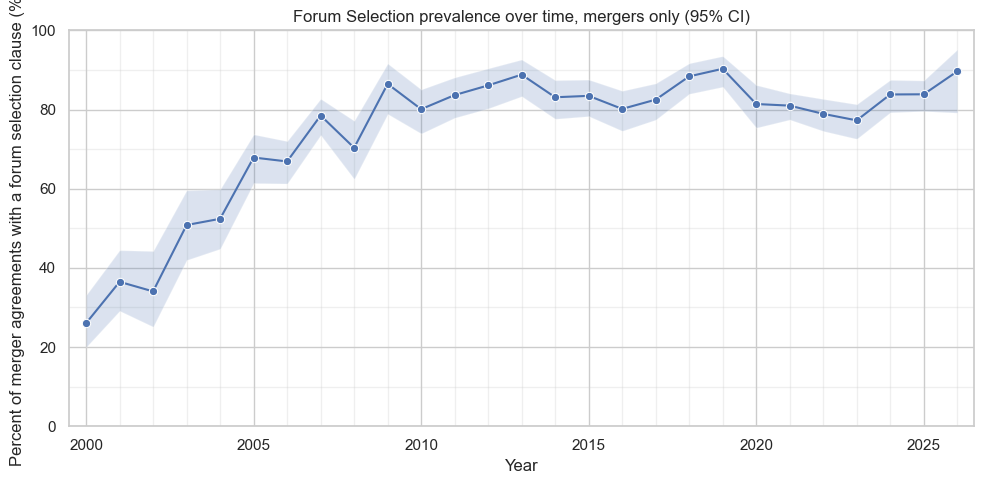

In [51]:
forum_clause_presence_df = (
    df_for.query('deal_type == "Merger"')
      .dropna(subset=["agreement_uuid", "year"])
      .assign(year=lambda d: d["year"].astype(int))
      .loc[:, ["agreement_uuid", "year"]]
      .assign(has_forum_clause=1)
)

yearly_totals = (
    merger_agreements_df.groupby("year", as_index=False)
                       .agg(n_agreements=("agreement_uuid", "size"))
)

yearly_with_clause = (
    forum_clause_presence_df.groupby("year", as_index=False)
                           .agg(k=("has_forum_clause", "sum"))
)

forum_prevalence_df = (
    yearly_totals.merge(yearly_with_clause, on="year", how="left")
                 .fillna({"k": 0})
                 .assign(k=lambda d: d["k"].astype(int))
                 .sort_values("year")
)

lo, hi = wilson_ci(forum_prevalence_df["k"], forum_prevalence_df["n_agreements"])
forum_prevalence_df["pct"] = (forum_prevalence_df["k"] / forum_prevalence_df["n_agreements"]) * 100
forum_prevalence_df["lo"] = lo * 100
forum_prevalence_df["hi"] = hi * 100

plt.figure(figsize=(10, 5))
sns.lineplot(data=forum_prevalence_df, x="year", y="pct", marker="o")

ax = plt.gca()
ax.fill_between(
    forum_prevalence_df["year"].to_numpy(),
    forum_prevalence_df["lo"].to_numpy(),
    forum_prevalence_df["hi"].to_numpy(),
    alpha=0.2,
)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Percent of merger agreements with a forum selection clause (%)")
plt.title("Forum Selection prevalence over time, mergers only (95% CI)")
plt.ylim(0, 100)
x_min, x_max = forum_prevalence_df["year"].min(), forum_prevalence_df["year"].max()
plt.xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

plt.tight_layout()
plt.show()


### See what states dominate forum selection clauses

#### Prep #1
Map clauses to jurisdictions

In [52]:
df_for = add_state_columns(df_for)


In [53]:
df_for[["mentions_delaware", "mentions_new_york", "only_delaware", "only_new_york"]].mean().round(3)


mentions_delaware    0.695
mentions_new_york    0.290
only_delaware        0.505
only_new_york        0.118
dtype: float64

#### Prep #2
Filter down to sections that are Forum Selection clauses only, rather than Forum Selection + Governing Law + ..., or else that have selected only a single state

In [54]:
taxonomy_lookup = fetch_taxonomy_lookup(session, API_BASE_URL)


In [55]:
df_for = add_taxonomy_text_columns(df_for, taxonomy_lookup)


In [56]:
df_for["standard_id_text"].value_counts().head(9)


standard_id_text
Forum Selection / Venue; Submission to Jurisdiction                                                                                                2893
Governing Law | Forum Selection / Venue; Submission to Jurisdiction                                                                                1556
Governing Law | Forum Selection / Venue; Submission to Jurisdiction | Waiver of Jury Trial                                                         1104
Forum Selection / Venue; Submission to Jurisdiction | Waiver of Jury Trial                                                                          526
Specific Performance; Injunction; Equitable Relief | Forum Selection / Venue; Submission to Jurisdiction                                            142
Governing Law | Forum Selection / Venue; Submission to Jurisdiction | Waiver of Jury Trial | Specific Performance; Injunction; Equitable Relief     109
Governing Law | Forum Selection / Venue; Submission to Jurisdiction | S

In [57]:
df_for["eligible"] = df_for.apply(
    lambda row: is_clause_family_eligible(row["standard_id"], row["states"], FORUM_CLAUSE_TYPE_ID),
    axis=1,
)
df_for["forum_only"] = df_for["standard_id"].apply(
    lambda value: is_clause_family_only(value, FORUM_CLAUSE_TYPE_ID)
)

df_for[df_for["eligible"]].shape


(5607, 22)

In [58]:
df_for_eligible = df_for[df_for["eligible"]].copy()
df_for_only = df_for[df_for["forum_only"]].copy()

print({"eligible": df_for_eligible.shape, "forum_only": df_for_only.shape})


{'eligible': (5607, 22), 'forum_only': (2893, 22)}


#### Single-state selections over time (mergers only)

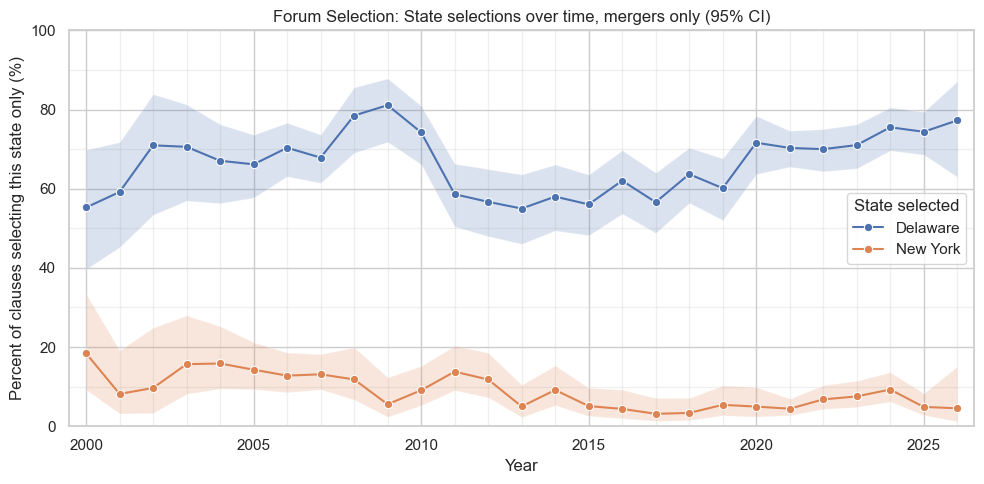

In [59]:
# Build one row per clause-state outcome and year
long_df = (
    df_for_eligible.query('deal_type == "Merger"')
      .dropna(subset=["year"])
      .assign(year=lambda d: d["year"].astype(int))
      .melt(
          id_vars=["year"],
          value_vars=["only_delaware", "only_new_york"],
          var_name="state",
          value_name="y",
      )
)

# Aggregate yearly successes (k) and sample sizes (n)
plot_df = (
    long_df.groupby(["year", "state"], as_index=False)
           .agg(k=("y", "sum"), n=("y", "size"))
)

lo, hi = wilson_ci(plot_df["k"], plot_df["n"])
plot_df["pct"] = (plot_df["k"] / plot_df["n"]) * 100
plot_df["lo"] = lo * 100
plot_df["hi"] = hi * 100

plot_df["state"] = plot_df["state"].map({
    "only_delaware": "Delaware",
    "only_new_york": "New York",
})

# Plot yearly rates with 95% Wilson confidence bands
plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_df, x="year", y="pct", hue="state", marker="o")

ax = plt.gca()
for state, sdf in plot_df.sort_values("year").groupby("state"):
    ax.fill_between(sdf["year"].to_numpy(), sdf["lo"].to_numpy(), sdf["hi"].to_numpy(), alpha=0.2)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Percent of clauses selecting this state only (%)")
plt.title("Forum Selection: State selections over time, mergers only (95% CI)")
plt.ylim(0, 100)
x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
plt.xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

ax.legend(title="State selected")

plt.tight_layout()
plt.show()


### See how the length and readability of forum selection clauses has evolved over time

In [60]:
xml_text = xml_to_text(df_for_only["xml"])
df_for_only["word_count"] = xml_text.str.split().str.len()


In [61]:
# Check for short outliers
short = df_for_only.sort_values(by="word_count", ascending=True).head(5)["xml"].tolist()

for item in short:
    print(item)
    print()
    print("#" * 40)
    print()



        <text>The Parties agree to resolve disputes concerning title matters pursuant to the arbitration procedure set forth in Section 15.6.</text>
      

########################################


        <text>As used in this Agreement, “Applicable Jurisdiction” means any of the United States, the European Union, Canada or Switzerland.</text>
      

########################################


        <text>The Bankruptcy Court shall retain jurisdiction for the purpose of determining any and all controversies and disputes arising under or in connection with, or for purposes of interpreting the provisions of, this Agreement.</text>
      

########################################


        <text>The Parties will, with regard to potential disputes between the Parties out of or in connection with this Agreement, enter simultaneously with the signing of this Agreement into an arbitration agreement as reflected in Schedule 11.04 (the "Arbitration Agreement").</text>
      

############

In [62]:
# Check for long outliers
long = df_for_only.sort_values(by="word_count", ascending=False).head(5)["xml"].tolist()

for item in long:
    print(item)
    print()
    print("#" * 40)
    print()



        <text>All disputes arising in connection with this Agreement, or further agreements or contracts resulting thereof, shall be finally settled in accordance with the Arbitration Rules of the Netherlands Arbitration Institute (“Nederlands Arbitrage Instituut”). The arbitral tribunal shall be composed of three arbitrators. The place of arbitration shall be Amsterdam. The arbitral procedure shall be conducted in the English language. The arbitral tribunal shall decide according to the rules of law (“naar de regelen des rechts”). Consolidation of the</text>
        <page>20</page>
        <pageUUID>9a47648e-ff02-11f0-b1b9-be44a5e954c9</pageUUID>
        <text>arbitral proceedings with other arbitral proceedings pending in The Netherlands, as provided in art. 1046 of The Netherlands Code of Civil Procedure is excluded.</text>
        <page>21</page>
        <pageUUID>9a476a92-ff02-11f0-b1b9-be44a5e954c9</pageUUID>
        <text>IN WITNESS WHEREOF this Agreement has been executed on t

#### 1. Word count scatter over time (mergers only)
- **Chart:** Clause length spans orders of magnitudes, so we use a log scale to enable comparisons.  
- **Limits:** Word count is descriptive and does not measure legal complexity directly.

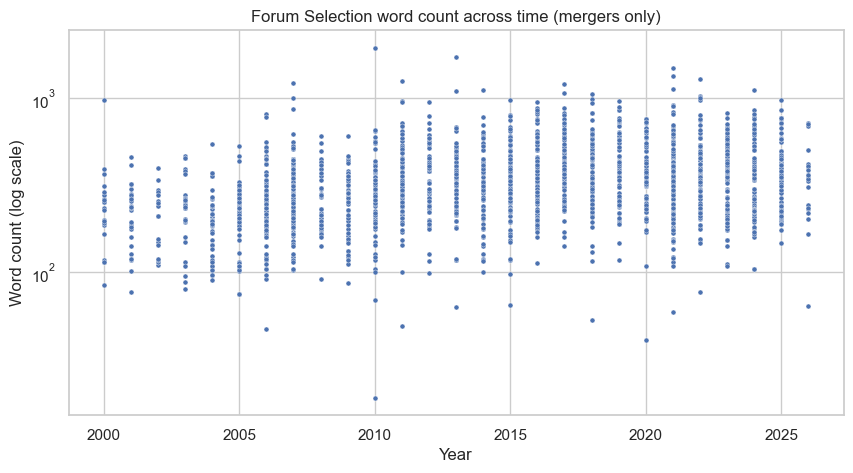

In [63]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_for_only[df_for_only["deal_type"] == "Merger"], x="year", y="word_count", s=13)
plt.yscale("log")
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Word count (log scale)")
_ = plt.title("Forum Selection word count across time (mergers only)")


#### 2. Word count distribution by year (mergers only)
- **Chart:** Violin widths summarize how the full clause-length distribution changes year to year.  
- **Limits:** Years with small sample sizes can look irregular.

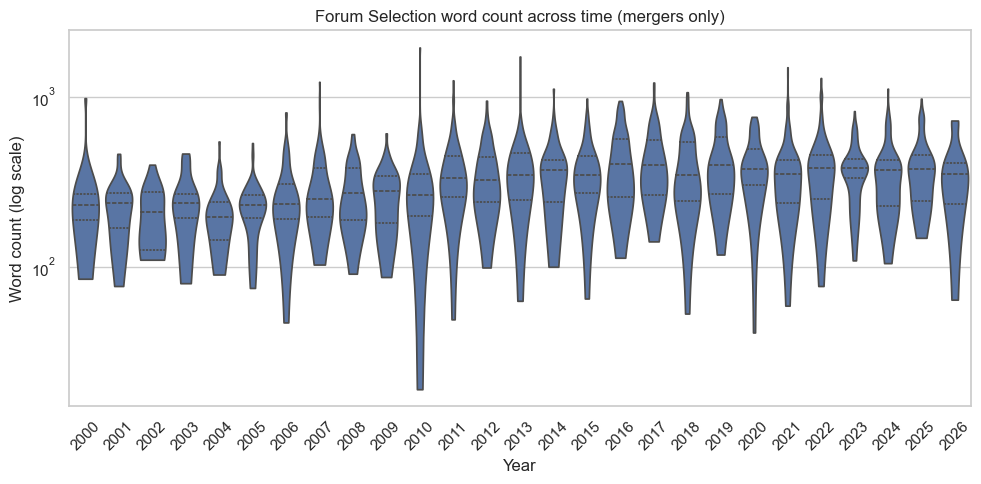

In [64]:
years = np.sort(df_for_only["year"].astype(int).unique())
df_for_only["year_cat"] = pd.Categorical(df_for_only["year"].astype(int), categories=years, ordered=True)

plt.figure(figsize=(10, 5))
ax = sns.violinplot(data=df_for_only[df_for_only["deal_type"] == "Merger"], x="year_cat", y="word_count", cut=0, inner="quartile", density_norm="width")
plt.yscale("log")

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=45)

ax.set_xlabel("Year")
ax.set_ylabel("Word count (log scale)")
ax.set_title("Forum Selection word count across time (mergers only)")
plt.tight_layout()


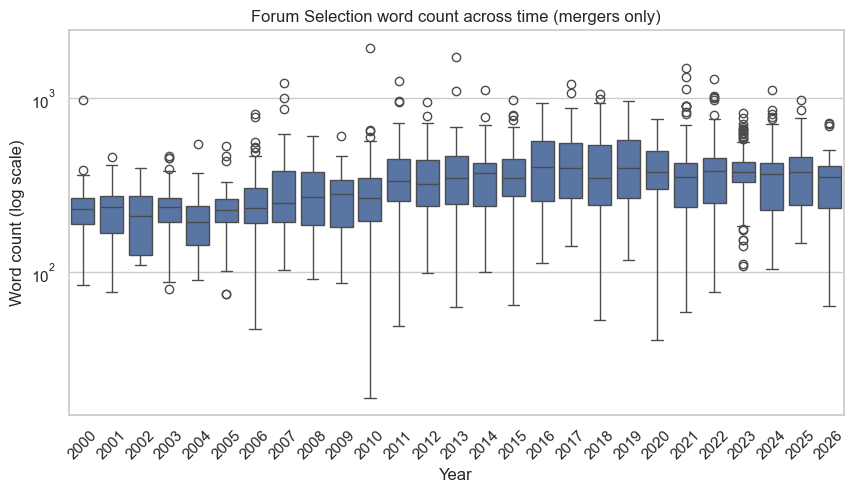

In [65]:
years = np.sort(df_for_only["year"].astype(int).unique())
df_for_only["year_cat"] = pd.Categorical(df_for_only["year"].astype(int), categories=years, ordered=True)

plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=df_for_only[df_for_only["deal_type"] == "Merger"], x="year_cat", y="word_count")
plt.yscale("log")

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=45)

ax.set_xlabel("Year")
ax.set_ylabel("Word count (log scale)")
_ = ax.set_title("Forum Selection word count across time (mergers only)")


#### 3. Readability by year (merger only)

In [66]:
df_for_only["readability"] = [textstat.flesch_kincaid_grade(x) for x in xml_text]


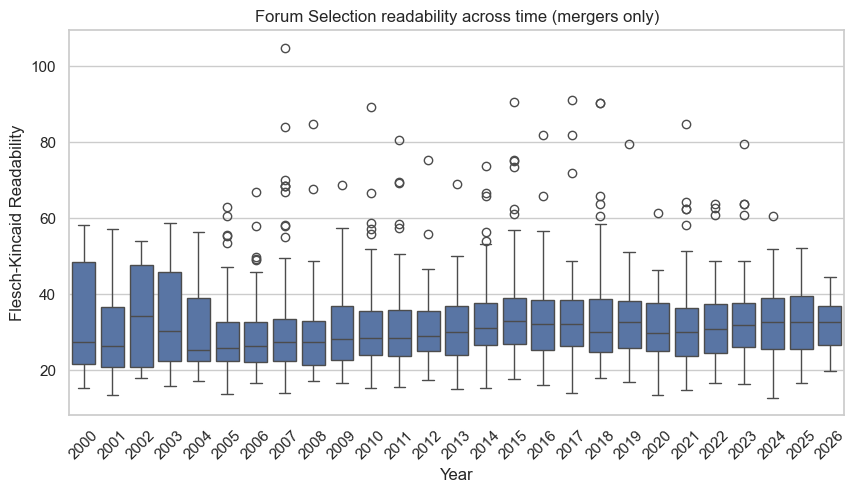

In [67]:
years = np.sort(df_for_only["year"].astype(int).unique())
df_for_only["year_cat"] = pd.Categorical(df_for_only["year"].astype(int), categories=years, ordered=True)

plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=df_for_only[df_for_only["deal_type"] == "Merger"], x="year_cat", y="readability")

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=45)

ax.set_xlabel("Year")
ax.set_ylabel("Flesch-Kincaid Readability")
_ = ax.set_title("Forum Selection readability across time (mergers only)")


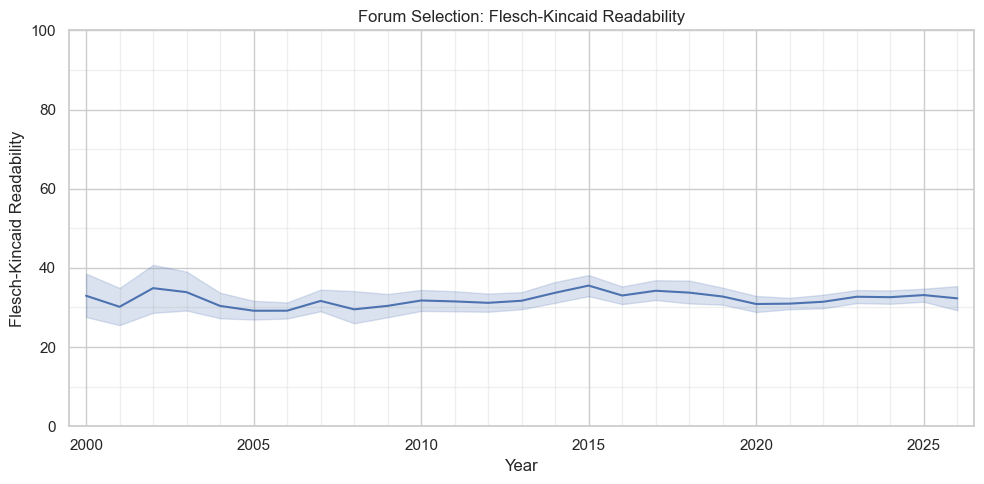

In [68]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_for_only[df_for_only["deal_type"] == "Merger"], x="year", y="readability")

ax = plt.gca()
plt.xlabel("Year")
plt.ylabel("Flesch-Kincaid Readability")
plt.title("Forum Selection: Flesch-Kincaid Readability")
plt.ylim(0, 100)
x_min, x_max = df_for_only["year"].min(), df_for_only["year"].max()
plt.xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

plt.tight_layout()
plt.show()


### See how the complexity of forum selection clauses has evolved over time

#### Prep

In [69]:
# Build a simple complexity proxy from readability, length, and multi-state selection.
# We min-max scale the continuous components to [0, 1] so they are roughly comparable
# to the binary multiple-states flag before averaging the three inputs.
df_for_only["multiple_states"] = df_for_only["states"].apply(lambda xs: int(len(xs) > 1))

readability_min = df_for_only["readability"].min()
readability_max = df_for_only["readability"].max()
df_for_only["readability_scaled"] = (
    (df_for_only["readability"] - readability_min) / (readability_max - readability_min)
)

# Word counts are highly right-skewed, so compress them before min-max scaling.
log_word_count = np.log1p(df_for_only["word_count"])
log_word_count_min = log_word_count.min()
log_word_count_max = log_word_count.max()
df_for_only["word_count_scaled"] = (
    (log_word_count - log_word_count_min) / (log_word_count_max - log_word_count_min)
)

df_for_only["complexity"] = df_for_only[["readability_scaled", "word_count_scaled", "multiple_states"]].mean(axis=1)


#### Complexity over time

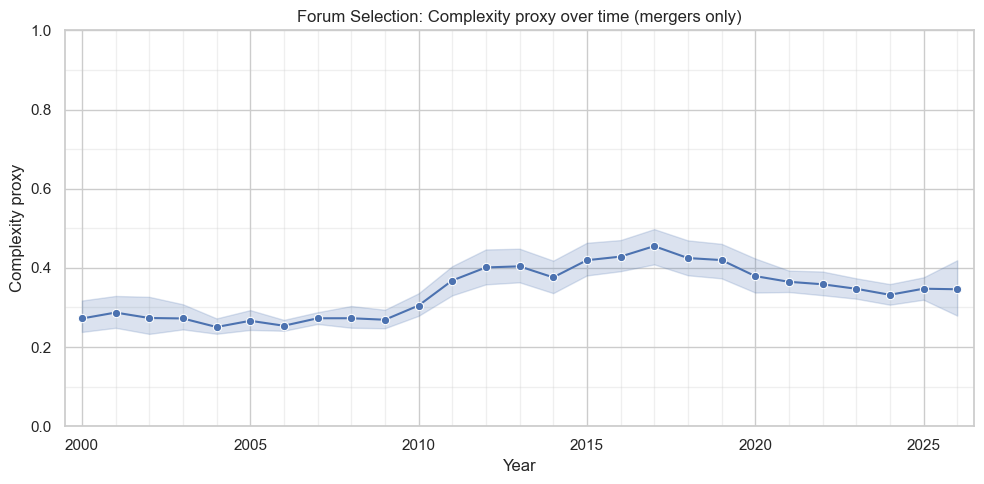

In [70]:
plot_df = (
    df_for_only.query('deal_type == "Merger"')
       .dropna(subset=["year", "complexity"])
       .assign(year=lambda d: d["year"].astype(int))
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_df, x="year", y="complexity", marker="o")

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xlabel("Year")
plt.ylabel("Complexity proxy")
plt.title("Forum Selection: Complexity proxy over time (mergers only)")
plt.ylim(0, 1)
x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
plt.xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

plt.tight_layout()
plt.show()
